In [1]:
# --- STEP 1: create_deltas_ratios.py ---
import pandas as pd
import numpy as np

# --- CONFIG ---
INPUT_FILE = "model_ready_feature_engineered.parquet"
OUTPUT_FILE = "intermediate_deltas_ratios.parquet"
GROUP_COL = "HARPNUM"
TIME_COL = "T_REC"
TIME_WINDOWS = ['6h', '12h']
CADENCE_SEC = 720  # 12 minutes in seconds

# Define features to process
BASE_SHARP_FEATURES = [
    'USFLUX', 'MEANGAM', 'MEANGBT', 'MEANGBZ', 'MEANGBH', 'TOTUSJH',
    'TOTPOT', 'MEANPOT', 'TOTUSJZ', 'SAVNCPP', 'ABSNJZH', 'AREA_ACR',
    'MEANJZH', 'R_VALUE', 'MEANALP', 'MEANSHR'
]

print(f"--- Running Step 1: Creating Deltas and Ratios ---")

# 1. LOAD & CLEAN
# ---------------------------------------------------------
df = pd.read_parquet(INPUT_FILE)
df[TIME_COL] = pd.to_datetime(df[TIME_COL])

# REMOVE REDUNDANCY: Drop exact duplicate rows (same HARP + same Time)
initial_count = len(df)
df = df.drop_duplicates(subset=[GROUP_COL, TIME_COL])
print(f"🧹 Data Cleaning: Removed {initial_count - len(df)} duplicate rows.")

# Sort is critical for .diff() to work correctly
df = df.sort_values(by=[GROUP_COL, TIME_COL]).reset_index(drop=True)


# 2. PHYSICS-INFORMED RATIOS (Vectorized)
# ---------------------------------------------------------
# Adding small epsilon (1e-9) to avoid DivisionByZero errors
print("➗ Calculating Physics Ratios...")
df['HELICITY_per_FLUX'] = df['TOTUSJH'] / (df['USFLUX'] + 1e-9)
df['VERT_CURRENT_per_FLUX'] = df['TOTUSJZ'] / (df['USFLUX'] + 1e-9)

# Update feature list to include new ratios
features_to_diff = BASE_SHARP_FEATURES + ['HELICITY_per_FLUX', 'VERT_CURRENT_per_FLUX']


# 3. TEMPORAL DELTAS (Optimized Loop)
# ---------------------------------------------------------
print("⏱️ Calculating Temporal Deltas...")

# OPTIMIZATION: Calculate period steps ONCE, outside the loop
window_steps = {
    window: int(pd.Timedelta(window).total_seconds() / CADENCE_SEC) 
    for window in TIME_WINDOWS
}

# Create a groupby object once to reuse (saves overhead)
grouped = df.groupby(GROUP_COL)

for feature in features_to_diff:
    for window, periods in window_steps.items():
        delta_col = f'{feature}_d{window}'
        # Using the pre-calculated steps
        df[delta_col] = grouped[feature].diff(periods=periods)

# 4. SAVE
# ---------------------------------------------------------
print(f"💾 Saving intermediate result to {OUTPUT_FILE}")
df.to_parquet(OUTPUT_FILE, index=False)
print(f"✅ Step 1 Complete. Dataset shape: {df.shape}")

--- Running Step 1: Creating Deltas and Ratios ---
🧹 Data Cleaning: Removed 0 duplicate rows.
➗ Calculating Physics Ratios...
⏱️ Calculating Temporal Deltas...
💾 Saving intermediate result to intermediate_deltas_ratios.parquet
✅ Step 1 Complete. Dataset shape: (658748, 60)


In [2]:
# --- STEP 2: create_rolling_stats.py ---
import pandas as pd
import numpy as np
from numba import jit

# --- CONFIG ---
INPUT_FILE = "intermediate_deltas_ratios.parquet"
OUTPUT_FILE = "intermediate_all_stats.parquet"
GROUP_COL = "HARPNUM"
TIME_COL = "T_REC"
ROLLING_WINDOW = 3

# --- NUMBA SLOPE FUNCTION (Optimized) ---
@jit(nopython=True)
def slope_func_numba(y):
    # Optimized: Removed np.arange allocation for every window
    n = len(y)
    if n < 2: return np.nan
    
    # Since x is always 0, 1, 2... we can compute sums directly
    sum_x = n * (n - 1) * 0.5
    sum_xx = (n - 1) * n * (2 * n - 1) / 6.0
    sum_y = np.sum(y)
    
    # Calculate sum_xy loop (faster than creating array for small windows)
    sum_xy = 0.0
    for i in range(n):
        sum_xy += i * y[i]
        
    denominator = (n * sum_xx) - (sum_x * sum_x)
    if denominator == 0: return np.nan
    
    return (n * sum_xy - sum_x * sum_y) / denominator

# -------------------------------------------------------------

print(f"--- Running Step 2: Generating Rolling Stats ---")
# 1. LOAD
df = pd.read_parquet(INPUT_FILE)
# Critical: Sort by Group and Time to ensure rolling is sequential
df = df.sort_values(by=[GROUP_COL, TIME_COL])

# Identify features created in Step 1
lagged_features = [c for c in df.columns if c.endswith(('_d6h', '_d12h'))]
print(f"🎯 Processing {len(lagged_features)} features...")

# Create GroupBy Object ONCE (sort=False is faster)
grouped = df.groupby(GROUP_COL, sort=False)[lagged_features]

# 2. BATCH CALCULATE STANDARD STATS (Vectorized)
# REMOVED REDUNDANCY: Instead of looping col-by-col, we calculate all stats at once
print("📊 Vectorized calculation of Mean, Std, Min, Max...")
stats_df = grouped.rolling(ROLLING_WINDOW, min_periods=1).agg(['mean', 'std', 'min', 'max'])

# Fix MultiIndex Columns (e.g., ('USFLUX_d6h', 'mean') -> 'USFLUX_d6h_mean3')
stats_df.columns = [f"{col}_{stat}{ROLLING_WINDOW}" for col, stat in stats_df.columns]
stats_df = stats_df.reset_index(level=0, drop=True) # Align with original df

# 3. CALCULATE SLOPE (Loop required for Custom Numba func)
print("📈 Calculating Slopes (Numba Accelerated)...")
slope_results = []

# We loop only for slope because custom apply is safer column-wise
for col in lagged_features:
    # Re-create rolling object for single column to apply custom func
    slope_series = df.groupby(GROUP_COL, sort=False)[col]\
                     .rolling(ROLLING_WINDOW, min_periods=2)\
                     .apply(slope_func_numba, raw=True)
    
    slope_results.append(
        slope_series.reset_index(level=0, drop=True).rename(f"{col}_slope{ROLLING_WINDOW}")
    )

# 4. MERGE & SAVE
print("🔗 Merging all features...")
slope_df = pd.concat(slope_results, axis=1)
final_df = pd.concat([df, stats_df, slope_df], axis=1)

print(f"💾 Saving intermediate result to {OUTPUT_FILE}")
final_df.to_parquet(OUTPUT_FILE, index=False)
print(f"✅ Step 2 Complete. Final shape: {final_df.shape}")

--- Running Step 2: Generating Rolling Stats ---
🎯 Processing 36 features...
📊 Vectorized calculation of Mean, Std, Min, Max...
📈 Calculating Slopes (Numba Accelerated)...
🔗 Merging all features...
💾 Saving intermediate result to intermediate_all_stats.parquet
✅ Step 2 Complete. Final shape: (658748, 240)


In [3]:
import pyarrow.parquet as pq
import pyarrow as pa
import pandas as pd
import numpy as np
import os
import gc

# =========================
# CONFIGURATION
# =========================
INPUT_FILE = "intermediate_all_stats.parquet"
OUTPUT_FILE = "final_arsenal_300_features_OPTIMIZED.parquet"
BATCH_SIZE = 10000  # Strict limit for RAM safety

print(f"--- Running Step 3: Ultra-Safe Batch Processing ---")

if not os.path.exists(INPUT_FILE):
    raise FileNotFoundError(f"Input file {INPUT_FILE} not found. Did Step 2 finish?")

# 1. Open the file for streaming
parquet_file = pq.ParquetFile(INPUT_FILE)
total_rows = parquet_file.metadata.num_rows
print(f"📦 Total rows to process: {total_rows:,}")

writer = None
rows_processed = 0

# 2. Iterate in fixed-size batches
# use_threads=False reduces memory overhead
try:
    for i, batch in enumerate(parquet_file.iter_batches(batch_size=BATCH_SIZE, use_threads=False)):
        
        # Convert to Pandas
        df_chunk = batch.to_pandas()
        
        # --- CLEANUP OPERATIONS ---
        
        # A. Identify Numeric Columns (Float/Int)
        numeric_cols = df_chunk.select_dtypes(include=[np.number]).columns
        
        # B. Handle Infinite & NaN (Vectorized)
        # Using .replace with dict is faster/cleaner in newer Pandas
        delta_columns = [c for c in df_chunk.columns if c.endswith(('_d6h', '_d12h', '_mean3', '_std3', '_min3', '_max3', '_slope3'))]
        df_chunk = df_chunk.dropna(subset=delta_columns)
        # C. Downcast float64 -> float32 (CRITICAL for Deep Learning & File Size)
        # We check types explicitly to avoid redundant casting
        f64_cols = df_chunk.select_dtypes(include=['float64']).columns
        if len(f64_cols) > 0:
            df_chunk[f64_cols] = df_chunk[f64_cols].astype('float32')

        # --- WRITE TO PARQUET ---
        
        # Convert back to Arrow Table
        # IMPORTANT: preserve_index=False removes the redundant index column
        table_chunk = pa.Table.from_pandas(df_chunk, preserve_index=False)
        
        # Initialize writer ONCE using the schema of the first chunk
        if writer is None:
            writer = pq.ParquetWriter(OUTPUT_FILE, table_chunk.schema)
        
        # Write and flush
        writer.write_table(table_chunk)
        
        rows_processed += len(df_chunk)
        if i % 5 == 0: # Print every 5th batch to reduce spam
            print(f"   - Processed {rows_processed:,} / {total_rows:,} rows...")
        
        # --- AGGRESSIVE MEMORY CLEANUP ---
        del df_chunk
        del table_chunk
        del batch
        gc.collect()

except KeyboardInterrupt:
    print("\n⚠️ Process interrupted! Saving partial file...")

finally:
    if writer:
        writer.close()

print(f"\n✅ SUCCESS: Final dataset saved to '{OUTPUT_FILE}'")
print(f"   - Final Rows: {rows_processed:,}")

--- Running Step 3: Ultra-Safe Batch Processing ---
📦 Total rows to process: 658,748
   - Processed 8,436 / 658,748 rows...
   - Processed 52,225 / 658,748 rows...
   - Processed 95,940 / 658,748 rows...
   - Processed 139,114 / 658,748 rows...
   - Processed 182,094 / 658,748 rows...
   - Processed 226,442 / 658,748 rows...
   - Processed 270,960 / 658,748 rows...
   - Processed 315,376 / 658,748 rows...
   - Processed 359,252 / 658,748 rows...
   - Processed 402,555 / 658,748 rows...
   - Processed 447,282 / 658,748 rows...
   - Processed 491,462 / 658,748 rows...
   - Processed 535,591 / 658,748 rows...
   - Processed 578,993 / 658,748 rows...

✅ SUCCESS: Final dataset saved to 'final_arsenal_300_features_OPTIMIZED.parquet'
   - Final Rows: 578,993


In [4]:
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit

# ==========================
# CONFIGURATION
# ==========================
DATA_FILE = "final_arsenal_300_features_OPTIMIZED.parquet"
GROUP_COL = "HARPNUM"
# Adjust 'flare' or 'classification' based on your actual column name
LABEL_COL = "flare" 

print("--- 🎲 ROLLING THE DICE FOR SCIENCE 🎲 ---")
print("Searching for a seed that creates a DIVERSE test set...")

df = pd.read_parquet(DATA_FILE)

# 1. Quick Label Fix (if needed)
if LABEL_COL not in df.columns:
    if 'classification' in df.columns:
        mapping = {'Non-flare': 0}
        df[LABEL_COL] = df['classification'].map(mapping).fillna(1).astype(int)
    else:
        print("❌ Error: Could not find label column.")
        exit()

# 2. Identify the AR Column
ar_col = 'NOAA_AR' if 'NOAA_AR' in df.columns else 'noaa_active_region'

# 3. The Search Loop
best_seed = -1
max_regions = 0

for seed in range(0, 100):
    # Try this seed
    gss = GroupShuffleSplit(n_splits=1, test_size=0.10, random_state=seed)
    train_idx, test_idx = next(gss.split(df, y=df[LABEL_COL], groups=df[GROUP_COL]))
    
    test_df = df.iloc[test_idx]
    
    # Check the POSITIVE class (Flares)
    flares_in_test = test_df[test_df[LABEL_COL] == 1]
    
    # How many unique Active Regions are in this test set?
    unique_ars = flares_in_test[ar_col].unique()
    count_ars = len(unique_ars)
    total_flares = len(flares_in_test)
    
    # We want a split with AT LEAST 5 different regions
    if count_ars >= 5:
        print(f"\n✅ Seed {seed} is a WINNER!")
        print(f"   • Unique Active Regions: {count_ars}")
        print(f"   • Total Flare Events:    {total_flares}")
        print(f"   • Regions List:          {unique_ars}")
        
        # Keep track of the most diverse one
        if count_ars > max_regions:
            max_regions = count_ars
            best_seed = seed

print("\n" + "="*40)
if best_seed != -1:
    print(f"🏆 BEST SEED FOUND: {best_seed}")
    print(f"   It creates a test set with {max_regions} different Active Regions.")
    print(f"👉 GO TO YOUR TRAINING SCRIPT AND SET: RANDOM_STATE = {best_seed}")
else:
    print("❌ No good seeds found in range 0-100. Try range(100, 200).")
print("="*40)

--- 🎲 ROLLING THE DICE FOR SCIENCE 🎲 ---
Searching for a seed that creates a DIVERSE test set...

✅ Seed 1 is a WINNER!
   • Unique Active Regions: 6
   • Total Flare Events:    1779
   • Regions List:          [11986 11990 12017 12106 12192 12249]

✅ Seed 10 is a WINNER!
   • Unique Active Regions: 5
   • Total Flare Events:    1064
   • Regions List:          [11977 12085 12113 12209 12242]

✅ Seed 17 is a WINNER!
   • Unique Active Regions: 5
   • Total Flare Events:    681
   • Regions List:          [11968 11990 12002 12106 12113]

✅ Seed 18 is a WINNER!
   • Unique Active Regions: 6
   • Total Flare Events:    737
   • Regions List:          [11977 12017 12077 12127 12182 12209]

✅ Seed 22 is a WINNER!
   • Unique Active Regions: 6
   • Total Flare Events:    2094
   • Regions List:          [12011 12017 12055 12192 12205 12222]

✅ Seed 24 is a WINNER!
   • Unique Active Regions: 5
   • Total Flare Events:    1775
   • Regions List:          [11967 11974 12209 12222 12241]

✅ See

In [2]:
import numpy as np
import pandas as pd
import joblib
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

# ==========================
# CONFIGURATION
# ==========================
DATA_FILE = "final_arsenal_300_features_OPTIMIZED.parquet"
BEST_PARAMS_FILE = "best_brf_params.joblib"
OUTPUT_FILE = "ablation_no_rolling_model.joblib"

GROUP_COL = "HARPNUM"
LABEL_COL = "flare"
RANDOM_STATE = 35
TEST_GROUP_FRAC = 0.10

# ==========================
# 1. LOAD DATA
# ==========================
print("\n--- 1. Loading Dataset ---")
df = pd.read_parquet(DATA_FILE)

if LABEL_COL not in df.columns and 'classification' in df.columns:
    mapping = {'Non-flare': 0}
    df[LABEL_COL] = df['classification'].map(mapping).fillna(1).astype(int)

# ==========================
# 2. DEFINE ABLATION FEATURE SET
# -- Remove ALL rolling stats, keep only base SHARP + deltas
# ==========================
explicit_drops = [LABEL_COL, GROUP_COL, 'classification', 'NOAA_AR']

# Rolling stat suffixes to exclude
rolling_suffixes = ('_mean3', '_std3', '_min3', '_max3', '_slope3')

numeric_df = df.select_dtypes(include=['number'])
feature_names = [
    c for c in numeric_df.columns
    if c not in explicit_drops
    and not c.endswith(rolling_suffixes)
]

print(f"✅ Ablation Feature Set: {len(feature_names)} features (rolling stats removed)")
print(f"   Sample features: {feature_names[:5]}")

# ==========================
# 3. SPLIT
# ==========================
print(f"\n--- 2. Creating Split (Seed {RANDOM_STATE}) ---")
gss = GroupShuffleSplit(n_splits=1, test_size=TEST_GROUP_FRAC, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(df, y=df[LABEL_COL], groups=df[GROUP_COL]))

train_df = df.iloc[train_idx].copy()
test_df = df.iloc[test_idx].copy()

X_train = train_df[feature_names].values
y_train = train_df[LABEL_COL].values

X_test = test_df[feature_names].values
y_test = test_df[LABEL_COL].values

print(f"✅ Train: {len(y_train)} samples, {sum(y_train)} flares")
print(f"✅ Test:  {len(y_test)} samples, {sum(y_test)} flares")

# ==========================
# 4. SCALE
# ==========================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================
# 5. TRAIN
# ==========================
print("\n--- 3. Training Ablation Model ---")
best_params = joblib.load(BEST_PARAMS_FILE)
best_params['random_state'] = RANDOM_STATE
best_params['n_jobs'] = -1

model = BalancedRandomForestClassifier(**best_params)
model.fit(X_train_scaled, y_train)
print("✅ Training Complete.")

# ==========================
# 6. THRESHOLD SCAN
# ==========================
print("\n--- 4. Threshold Scan (0.30 to 0.95) ---")
y_probs = model.predict_proba(X_test_scaled)[:, 1]

best_tss = 0
best_threshold = 0.5
results = []

for thresh in np.linspace(0.30, 0.95, 66):
    y_pred = (y_probs >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    tss = recall - fpr
    results.append((round(thresh, 3), tss, recall, fp))
    if tss > best_tss:
        best_tss = tss
        best_threshold = thresh

print(f"\n✅ Best Threshold: {best_threshold:.2f} → TSS: {best_tss:.4f}")
print("\nTop 10 Thresholds by TSS:")
results_sorted = sorted(results, key=lambda x: x[1], reverse=True)[:10]
for thresh, tss, recall, fp in results_sorted:
    print(f"   Threshold: {thresh:.2f} | TSS: {tss:.4f} | Recall: {recall:.4f} | FP: {fp}")

# ==========================
# 7. FINAL EVALUATION
# ==========================
print(f"\n--- 5. Final Evaluation at Threshold {best_threshold:.2f} ---")
y_pred_final = (y_probs >= best_threshold).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_final).ravel()

recall = tp / (tp + fn) if (tp + fn) > 0 else 0
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
tss = recall - (fp / (fp + tn))

# Train TSS for overfitting check
y_probs_train = model.predict_proba(X_train_scaled)[:, 1]
y_pred_train = (y_probs_train >= best_threshold).astype(int)
tn_tr, fp_tr, fn_tr, tp_tr = confusion_matrix(y_train, y_pred_train).ravel()
recall_tr = tp_tr / (tp_tr + fn_tr) if (tp_tr + fn_tr) > 0 else 0
fpr_tr = fp_tr / (fp_tr + tn_tr) if (fp_tr + tn_tr) > 0 else 0
tss_train = recall_tr - fpr_tr

print("\n" + "="*40)
print("ABLATION RESULTS (No Rolling Stats)")
print("="*40)
print(f"Features Used: {len(feature_names)}")
print(f"Confusion Matrix:\n[[{tn}  {fp}]\n [{fn}    {tp}]]")
print("-"*25)
print(f"TSS SCORE:    {tss:.4f}")
print(f"RECALL:       {recall:.4f}")
print(f"PRECISION:    {precision:.4f}")
print(f"FALSE POS:    {fp}")
print("-"*25)
print(f"OVERFITTING CHECK:")
print(f"   Train TSS: {tss_train:.4f}")
print(f"   Test TSS:  {tss:.4f}")
gap = tss_train - tss
if gap > 0.15:
    print(f"WARNING: Overfitting gap still present (Gap: {gap:.4f})")
    print("   Rolling stats are NOT the sole cause -- investigate further.")
else:
    print(f"OK: Gap reduced significantly (Gap: {gap:.4f})")
    print("   Rolling stats were causing overfitting -- confirmed.")
print("="*40)

# ==========================
# 8. COMPARISON SUMMARY
# ==========================
print("\n" + "="*40)
print("COMPARISON SUMMARY")
print("="*40)
print(f"Full Model (with rolling):  TSS=0.6583, Gap=0.1810")
print(f"Ablation (no rolling):      TSS={tss:.4f}, Gap={gap:.4f}")
print("="*40)

# ==========================
# 9. SAVE
# ==========================
final_bundle = {
    "model": model,
    "scaler": scaler,
    "features": feature_names,
    "threshold": best_threshold,
    "metrics": {
        "tss": tss,
        "tss_train": tss_train,
        "recall": recall,
        "precision": precision,
        "fp": fp
    },
    "note": "Ablation model -- rolling stats removed"
}
joblib.dump(final_bundle, OUTPUT_FILE)
print(f"\n✅ SAVED: {OUTPUT_FILE}")


--- 1. Loading Dataset ---
✅ Ablation Feature Set: 55 features (rolling stats removed)
   Sample features: ['USFLUX', 'MEANGAM', 'MEANGBT', 'MEANGBZ', 'MEANGBH']

--- 2. Creating Split (Seed 35) ---
✅ Train: 517418 samples, 5913 flares
✅ Test:  61575 samples, 1468 flares

--- 3. Training Ablation Model ---
✅ Training Complete.

--- 4. Threshold Scan (0.30 to 0.95) ---

✅ Best Threshold: 0.45 → TSS: 0.6870

Top 10 Thresholds by TSS:
   Threshold: 0.45 | TSS: 0.6870 | Recall: 0.9360 | FP: 14967
   Threshold: 0.44 | TSS: 0.6865 | Recall: 0.9380 | FP: 15116
   Threshold: 0.43 | TSS: 0.6845 | Recall: 0.9387 | FP: 15281
   Threshold: 0.42 | TSS: 0.6838 | Recall: 0.9407 | FP: 15442
   Threshold: 0.46 | TSS: 0.6832 | Recall: 0.9298 | FP: 14827
   Threshold: 0.41 | TSS: 0.6818 | Recall: 0.9414 | FP: 15605
   Threshold: 0.55 | TSS: 0.6802 | Recall: 0.9108 | FP: 13856
   Threshold: 0.54 | TSS: 0.6795 | Recall: 0.9114 | FP: 13943
   Threshold: 0.40 | TSS: 0.6792 | Recall: 0.9421 | FP: 15803
   Th

--- Loading Data & Model ---
--- Scanning Thresholds ---
✅ Saved Graph to 'operational_tradeoff_curve.png'


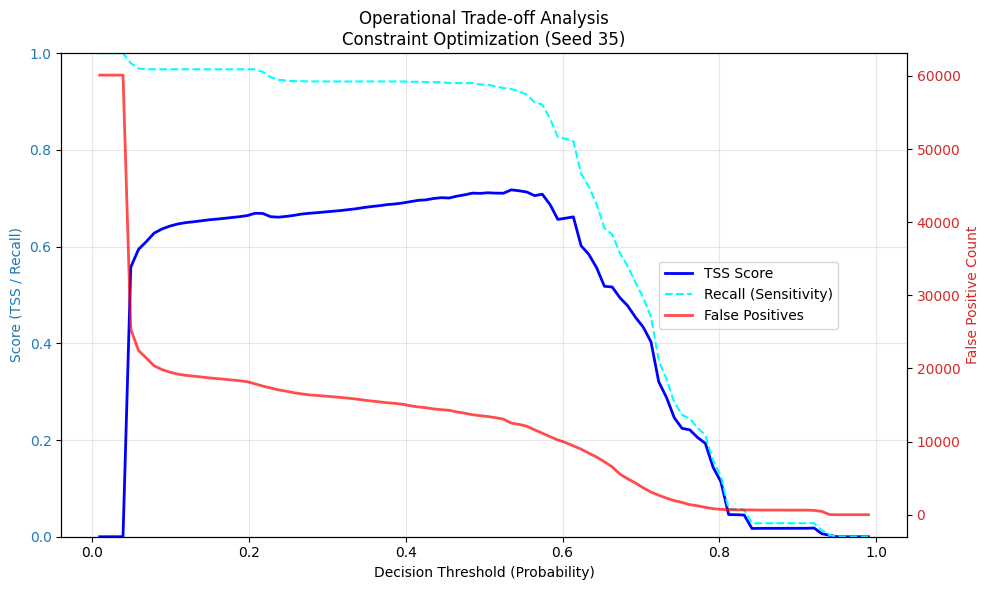

In [6]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import confusion_matrix

# ==========================
# CONFIGURATION
# ==========================
MODEL_FILE = "best_xgb_params.joblib"
DATA_FILE = "final_arsenal_300_features_OPTIMIZED.parquet"
RANDOM_STATE = 35  # The "Golden Seed"
#CHOSEN_THRESHOLD = 0.44  # The one we found in the previous step

# ==========================
# 1. PREPARE DATA (Exact same split)
# ==========================
print("--- Loading Data & Model ---")
bundle = joblib.load(MODEL_FILE)
model = bundle['model']
scaler = bundle['scaler']
features = bundle['features']

df = pd.read_parquet(DATA_FILE)
if 'flare' not in df.columns:
    mapping = {'Non-flare': 0}
    df['flare'] = df['classification'].map(mapping).fillna(1).astype(int)

gss = GroupShuffleSplit(n_splits=1, test_size=0.10, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(df, y=df['flare'], groups=df['HARPNUM']))
test_df = df.iloc[test_idx].copy()

X_test_scaled = scaler.transform(test_df[features].values)
y_test = test_df['flare'].values
y_probs = model.predict_proba(X_test_scaled)[:, 1]

# ==========================
# 2. RUN THE SCAN
# ==========================
thresholds = np.linspace(0.01, 0.99, 100)
tss_scores = []
recalls = []
fps = []

print("--- Scanning Thresholds ---")
for thresh in thresholds:
    y_pred = (y_probs >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    recall = tp / (tp + fn) if (tp+fn)>0 else 0
    spec = tn / (tn + fp) if (tn+fp)>0 else 0
    tss = recall + spec - 1
    
    tss_scores.append(tss)
    recalls.append(recall)
    fps.append(fp)

# ==========================
# 3. PLOT THE "SWEET SPOT"
# ==========================
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot Metrics (Left Axis)
ax1.set_xlabel('Decision Threshold (Probability)')
ax1.set_ylabel('Score (TSS / Recall)', color='tab:blue')
ax1.plot(thresholds, tss_scores, label='TSS Score', color='blue', linewidth=2)
ax1.plot(thresholds, recalls, label='Recall (Sensitivity)', color='cyan', linestyle='--')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_ylim(0, 1.0)
ax1.grid(True, alpha=0.3)

# Plot False Positives (Right Axis)
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
ax2.set_ylabel('False Positive Count', color='tab:red')  # we already handled the x-label with ax1
ax2.plot(thresholds, fps, label='False Positives', color='red', linewidth=2, alpha=0.7)
ax2.tick_params(axis='y', labelcolor='tab:red')

# Mark the Chosen Point
#plt.axvline(x=CHOSEN_THRESHOLD, color='green', linestyle=':', linewidth=2, label=f'Chosen Operation Point ({CHOSEN_THRESHOLD})')

# Add Title and Layout
plt.title(f'Operational Trade-off Analysis\nConstraint Optimization (Seed {RANDOM_STATE})')
fig.legend(loc="center right", bbox_to_anchor=(0.85, 0.5))
plt.tight_layout()

# Save
plt.savefig("operational_tradeoff_curve.png", dpi=300)
print("✅ Saved Graph to 'operational_tradeoff_curve.png'")
plt.show()

--- Loading Model for Feature Selection Analysis ---

--- 📊 SCIENTIFIC FEATURE SELECTION REPORT ---
Total Features: 55

1. The 'Pareto' Cutoff (Cumulative Importance):
   • Top 23 features explain 90% of the model's predictive power.
   • Top 30 features explain 95% of the model's predictive power.

2. The Top 10 Features (The Heavy Lifters):
   1. TOTUSJZ              (Score: 0.1881)
   2. USFLUX               (Score: 0.1821)
   3. TOTUSJH              (Score: 0.1308)
   4. TOTPOT               (Score: 0.0579)
   5. R_VALUE              (Score: 0.0468)
   6. AREA_ACR_d12h        (Score: 0.0350)
   7. TOTUSJZ_d12h         (Score: 0.0346)
   8. AREA_ACR             (Score: 0.0268)
   9. MEANGBZ              (Score: 0.0214)
   10. TOTUSJH_d12h         (Score: 0.0192)
   11. HELICITY_per_FLUX    (Score: 0.0166)
   12. VERT_CURRENT_per_FLUX (Score: 0.0163)
   13. MEANGBT              (Score: 0.0163)
   14. MEANGBH              (Score: 0.0140)
   15. MEANJZH              (Score: 0.0129)
   

<Figure size 640x480 with 0 Axes>

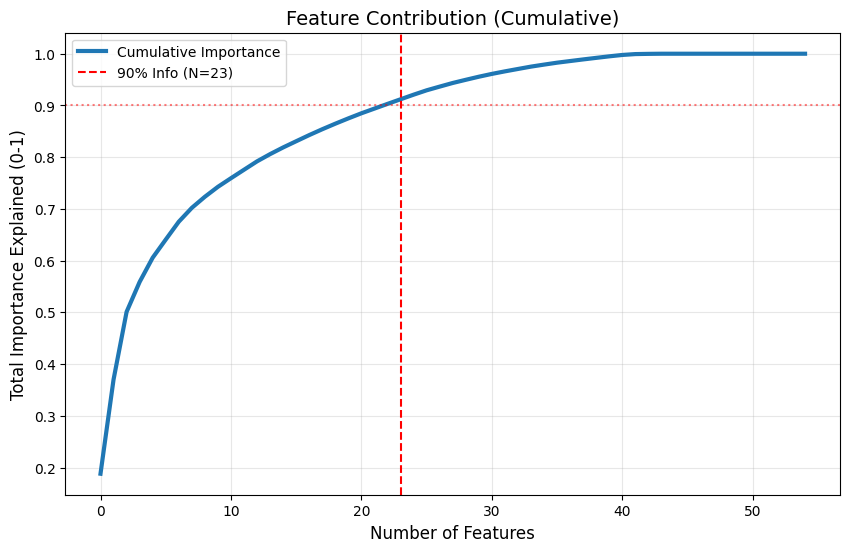

In [2]:
import joblib
import numpy as np
import matplotlib.pyplot as plt

# ==========================
# CONFIGURATION
# ==========================
MODEL_FILE = "best_xgb_params.joblib"

# ==========================
# RUN ANALYSIS
# ==========================
print(f"--- Loading Model for Feature Selection Analysis ---")
bundle = joblib.load(MODEL_FILE)
model = bundle['model']
feature_names = np.array(bundle['features'])

# 1. Get Sorted Importances
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
sorted_importances = importances[indices]
sorted_features = feature_names[indices]

# 2. Calculate Cumulative Sum (The "Total Brain Power")
cumulative_importance = np.cumsum(sorted_importances)

# 3. Find the "90% Explained" Cutoff
cutoff_90 = np.argmax(cumulative_importance >= 0.90) + 1
cutoff_95 = np.argmax(cumulative_importance >= 0.95) + 1

# 4. Find the "Elbow" (Largest Drop in Importance)
# We look for the point where the drop starts to stabilize
diffs = np.diff(sorted_importances) # Calculate drop from one feature to next
# The "Knee" is often where the 2nd derivative is highest, or simple heuristic:
# Let's use the 90% threshold as the scientific standard.

print(f"\n--- 📊 SCIENTIFIC FEATURE SELECTION REPORT ---")
print(f"Total Features: {len(feature_names)}")
print(f"\n1. The 'Pareto' Cutoff (Cumulative Importance):")
print(f"   • Top {cutoff_90} features explain 90% of the model's predictive power.")
print(f"   • Top {cutoff_95} features explain 95% of the model's predictive power.")

print(f"\n2. The Top 10 Features (The Heavy Lifters):")
for i in range(23):
    print(f"   {i+1}. {sorted_features[i]:<20} (Score: {sorted_importances[i]:.4f})")

print(f"\n3. The 'Drop' Analysis:")
print(f"   Gap between #4 and #5: {sorted_importances[3] - sorted_importances[4]:.4f}")
print(f"   Gap between #10 and #11: {sorted_importances[9] - sorted_importances[10]:.4f}")
print(f"   Gap between #50 and #51: {sorted_importances[49] - sorted_importances[50]:.4f}")

PLOT_OUTPUT="Feature_contributon.png"
plt.savefig(PLOT_OUTPUT, dpi=300, bbox_inches='tight')
print(f"✅ Figure saved successfully.")

# Plotting the Curve
plt.figure(figsize=(10, 6))
plt.plot(cumulative_importance, linewidth=3, color='#1f77b4', label='Cumulative Importance')
plt.axvline(cutoff_90, color='red', linestyle='--', label=f'90% Info (N={cutoff_90})')
plt.axhline(0.90, color='red', linestyle=':', alpha=0.5)
plt.title('Feature Contribution (Cumulative)', fontsize=14)
plt.xlabel('Number of Features', fontsize=12)
plt.ylabel('Total Importance Explained (0-1)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [8]:
#This code if we assume top 25 featues from the gini importance results actually degreaded the TSS, but for proff im executing it:
import numpy as np
import pandas as pd
import joblib
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

# ==========================
# CONFIGURATION
# ==========================
DATA_FILE = "final_arsenal_300_features_OPTIMIZED.parquet"
BEST_PARAMS_FILE = "best_brf_params.joblib"
OUTPUT_FILE = "ablation_top25_model.joblib"


GROUP_COL = "HARPNUM"
LABEL_COL = "flare"
RANDOM_STATE = 35
TEST_GROUP_FRAC = 0.10

# ==========================
# 1. LOAD DATA
# ==========================
print("\n--- 1. Loading Dataset ---")
df = pd.read_parquet(DATA_FILE)

if LABEL_COL not in df.columns and 'classification' in df.columns:
    mapping = {'Non-flare': 0}
    df[LABEL_COL] = df['classification'].map(mapping).fillna(1).astype(int)

# ==========================
# 2. DEFINE ABLATION FEATURE SET
# -- Remove ALL rolling stats, keep only base SHARP + deltas
# ==========================
explicit_drops = [LABEL_COL, GROUP_COL, 'classification', 'NOAA_AR']

# Rolling stat suffixes to exclude
top_25 = [
    'USFLUX', 'TOTPOT', 'MEANGBT', 'AREA_ACR', 'MEANGBZ',
    'TOTUSJH', 'TOTUSJZ', 'LAT_FWT', 'HELICITY_per_FLUX', 'TOTUSJZ_d12h',
    'VERT_CURRENT_per_FLUX', 'TOTUSJH_d12h', 'USFLUX_d12h', 'MEANGBH', 'SAVNCPP',
    'USFLUX_d6h', 'MEANPOT', 'MEANSHR', 'TOTUSJZ_d6h', 'R_VALUE_d12h',
    'MEANGAM', 'TOTPOT_d6h', 'R_VALUE', 'SAVNCPP_d12h', 'MEANALP'
]

feature_names = [c for c in top_25 if c in df.columns]

print(f"✅ Top 25 Feature Set: {len(feature_names)} features")
print(f"   Features: {feature_names}")

# ==========================
# 3. SPLIT
# ==========================
print(f"\n--- 2. Creating Split (Seed {RANDOM_STATE}) ---")
gss = GroupShuffleSplit(n_splits=1, test_size=TEST_GROUP_FRAC, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(df, y=df[LABEL_COL], groups=df[GROUP_COL]))

train_df = df.iloc[train_idx].copy()
test_df = df.iloc[test_idx].copy()

X_train = train_df[feature_names].values
y_train = train_df[LABEL_COL].values

X_test = test_df[feature_names].values
y_test = test_df[LABEL_COL].values

print(f"✅ Train: {len(y_train)} samples, {sum(y_train)} flares")
print(f"✅ Test:  {len(y_test)} samples, {sum(y_test)} flares")

# ==========================
# 4. SCALE
# ==========================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================
# 5. TRAIN
# ==========================
print("\n--- 3. Training Ablation Model ---")
best_params = joblib.load(BEST_PARAMS_FILE)
best_params['random_state'] = RANDOM_STATE
best_params['n_jobs'] = -1

model = BalancedRandomForestClassifier(**best_params)
model.fit(X_train_scaled, y_train)
print("✅ Training Complete.")

# ==========================
# 6. THRESHOLD SCAN
# ==========================
print("\n--- 4. Threshold Scan (0.30 to 0.95) ---")
y_probs = model.predict_proba(X_test_scaled)[:, 1]

best_tss = 0
best_threshold = 0.5
results = []

for thresh in np.linspace(0.30, 0.95, 66):
    y_pred = (y_probs >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    tss = recall - fpr
    results.append((round(thresh, 3), tss, recall, fp))
    if tss > best_tss:
        best_tss = tss
        best_threshold = thresh

print(f"\n✅ Best Threshold: {best_threshold:.2f} → TSS: {best_tss:.4f}")
print("\nTop 10 Thresholds by TSS:")
results_sorted = sorted(results, key=lambda x: x[1], reverse=True)[:10]
for thresh, tss, recall, fp in results_sorted:
    print(f"   Threshold: {thresh:.2f} | TSS: {tss:.4f} | Recall: {recall:.4f} | FP: {fp}")

# ==========================
# 7. FINAL EVALUATION
# ==========================
print(f"\n--- 5. Final Evaluation at Threshold {best_threshold:.2f} ---")
y_pred_final = (y_probs >= best_threshold).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_final).ravel()

recall = tp / (tp + fn) if (tp + fn) > 0 else 0
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
tss = recall - (fp / (fp + tn))

# Train TSS for overfitting check
y_probs_train = model.predict_proba(X_train_scaled)[:, 1]
y_pred_train = (y_probs_train >= best_threshold).astype(int)
tn_tr, fp_tr, fn_tr, tp_tr = confusion_matrix(y_train, y_pred_train).ravel()
recall_tr = tp_tr / (tp_tr + fn_tr) if (tp_tr + fn_tr) > 0 else 0
fpr_tr = fp_tr / (fp_tr + tn_tr) if (fp_tr + tn_tr) > 0 else 0
tss_train = recall_tr - fpr_tr

print("\n" + "="*40)
print("ABLATION RESULTS (No Rolling Stats)")
print("="*40)
print(f"Features Used: {len(feature_names)}")
print(f"Confusion Matrix:\n[[{tn}  {fp}]\n [{fn}    {tp}]]")
print("-"*25)
print(f"TSS SCORE:    {tss:.4f}")
print(f"RECALL:       {recall:.4f}")
print(f"PRECISION:    {precision:.4f}")
print(f"FALSE POS:    {fp}")
print("-"*25)
print(f"OVERFITTING CHECK:")
print(f"   Train TSS: {tss_train:.4f}")
print(f"   Test TSS:  {tss:.4f}")
gap = tss_train - tss
if gap > 0.15:
    print(f"WARNING: Overfitting gap still present (Gap: {gap:.4f})")
    print("   Rolling stats are NOT the sole cause -- investigate further.")
else:
    print(f"OK: Gap reduced significantly (Gap: {gap:.4f})")
    print("   Rolling stats were causing overfitting -- confirmed.")
print("="*40)

# ==========================
# 8. COMPARISON SUMMARY
# ==========================
print("\n" + "="*40)
print("COMPARISON SUMMARY")
print("="*40)
print(f"Full Model (55 features):  TSS=0.6870, Gap=0.1410")
print(f"Top 25 Model:              TSS={tss:.4f}, Gap={gap:.4f}")
print("="*40)

# ==========================
# 9. SAVE
# ==========================
final_bundle = {
    "model": model,
    "scaler": scaler,
    "features": feature_names,
    "threshold": best_threshold,
    "metrics": {
        "tss": tss,
        "tss_train": tss_train,
        "recall": recall,
        "precision": precision,
        "fp": fp
    },
    "note": "Ablation model -- rolling stats removed"
}
joblib.dump(final_bundle, OUTPUT_FILE)
print(f"\n✅ SAVED: {OUTPUT_FILE}")


--- 1. Loading Dataset ---
✅ Top 25 Feature Set: 25 features
   Features: ['USFLUX', 'TOTPOT', 'MEANGBT', 'AREA_ACR', 'MEANGBZ', 'TOTUSJH', 'TOTUSJZ', 'LAT_FWT', 'HELICITY_per_FLUX', 'TOTUSJZ_d12h', 'VERT_CURRENT_per_FLUX', 'TOTUSJH_d12h', 'USFLUX_d12h', 'MEANGBH', 'SAVNCPP', 'USFLUX_d6h', 'MEANPOT', 'MEANSHR', 'TOTUSJZ_d6h', 'R_VALUE_d12h', 'MEANGAM', 'TOTPOT_d6h', 'R_VALUE', 'SAVNCPP_d12h', 'MEANALP']

--- 2. Creating Split (Seed 35) ---
✅ Train: 517418 samples, 5913 flares
✅ Test:  61575 samples, 1468 flares

--- 3. Training Ablation Model ---
✅ Training Complete.

--- 4. Threshold Scan (0.30 to 0.95) ---

✅ Best Threshold: 0.33 → TSS: 0.6733

Top 10 Thresholds by TSS:
   Threshold: 0.33 | TSS: 0.6733 | Recall: 0.9230 | FP: 15013
   Threshold: 0.34 | TSS: 0.6729 | Recall: 0.9210 | FP: 14909
   Threshold: 0.32 | TSS: 0.6715 | Recall: 0.9237 | FP: 15160
   Threshold: 0.35 | TSS: 0.6710 | Recall: 0.9176 | FP: 14820
   Threshold: 0.31 | TSS: 0.6693 | Recall: 0.9237 | FP: 15289
   Thres

In [9]:
#With rolling stats
import numpy as np
import pandas as pd
import joblib
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import confusion_matrix

# ==========================
# CONFIGURATION
# ==========================
DATA_FILE = "final_arsenal_300_features_OPTIMIZED.parquet"
BUNDLE_FILE = "production_ready_model_clean.joblib"

GROUP_COL = "HARPNUM"
LABEL_COL = "flare"
RANDOM_STATE = 35
TEST_GROUP_FRAC = 0.10

# ==========================
# 1. LOAD
# ==========================
print("\n--- 1. Loading ---")
df = pd.read_parquet(DATA_FILE)

if LABEL_COL not in df.columns and 'classification' in df.columns:
    mapping = {'Non-flare': 0}
    df[LABEL_COL] = df['classification'].map(mapping).fillna(1).astype(int)

bundle = joblib.load(BUNDLE_FILE)
model = bundle['model']
scaler = bundle['scaler']
feature_names = bundle['features']

# ==========================
# 2. RECREATE SPLIT
# ==========================
print(f"\n--- 2. Recreating Split (Seed {RANDOM_STATE}) ---")
gss = GroupShuffleSplit(n_splits=1, test_size=TEST_GROUP_FRAC, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(df, y=df[LABEL_COL], groups=df[GROUP_COL]))

test_df = df.iloc[test_idx].copy()
train_df = df.iloc[train_idx].copy()

X_test = test_df[feature_names].values
y_test = test_df[LABEL_COL].values
X_test_scaled = scaler.transform(X_test)

X_train = train_df[feature_names].values
y_train = train_df[LABEL_COL].values
X_train_scaled = scaler.transform(X_train)

# ==========================
# 3. EXTENDED THRESHOLD SCAN
# ==========================
print("\n--- 3. Extended Threshold Scan (0.30 to 0.95) ---")
y_probs = model.predict_proba(X_test_scaled)[:, 1]

best_tss = 0
best_threshold = 0.5
results = []

for thresh in np.linspace(0.30, 0.95, 66):
    y_pred = (y_probs >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    tss = recall - fpr
    results.append((round(thresh, 3), tss, recall, fp))
    if tss > best_tss:
        best_tss = tss
        best_threshold = thresh

print(f"\n✅ Best Threshold: {best_threshold:.2f} → TSS: {best_tss:.4f}")
print("\nTop 10 Thresholds by TSS:")
results_sorted = sorted(results, key=lambda x: x[1], reverse=True)[:10]
for thresh, tss, recall, fp in results_sorted:
    print(f"   Threshold: {thresh:.2f} | TSS: {tss:.4f} | Recall: {recall:.4f} | FP: {fp}")

# ==========================
# 4. FINAL EVALUATION AT BEST THRESHOLD
# ==========================
print(f"\n--- 4. Final Evaluation at Threshold {best_threshold:.2f} ---")
y_pred_final = (y_probs >= best_threshold).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_final).ravel()

recall = tp / (tp + fn) if (tp + fn) > 0 else 0
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
tss = recall - (fp / (fp + tn))

# Train TSS for overfitting check
y_probs_train = model.predict_proba(X_train_scaled)[:, 1]
y_pred_train = (y_probs_train >= best_threshold).astype(int)
tn_tr, fp_tr, fn_tr, tp_tr = confusion_matrix(y_train, y_pred_train).ravel()
recall_tr = tp_tr / (tp_tr + fn_tr) if (tp_tr + fn_tr) > 0 else 0
fpr_tr = fp_tr / (fp_tr + tn_tr) if (fp_tr + tn_tr) > 0 else 0
tss_train = recall_tr - fpr_tr

print("\n" + "="*40)
print("FINAL RESULTS")
print("="*40)
print(f"Confusion Matrix:\n[[{tn}  {fp}]\n [{fn}    {tp}]]")
print("-"*25)
print(f"TSS SCORE:    {tss:.4f}")
print(f"RECALL:       {recall:.4f}")
print(f"PRECISION:    {precision:.4f}")
print(f"FALSE POS:    {fp}")
print("-"*25)
print(f"OVERFITTING CHECK:")
print(f"   Train TSS: {tss_train:.4f}")
print(f"   Test TSS:  {tss:.4f}")
gap = tss_train - tss
if gap > 0.15:
    print(f"WARNING: Possible overfitting (Gap: {gap:.4f})")
else:
    print(f"OK: Model generalizes well (Gap: {gap:.4f})")
print("="*40)


--- 1. Loading ---

--- 2. Recreating Split (Seed 35) ---

--- 3. Extended Threshold Scan (0.30 to 0.95) ---

✅ Best Threshold: 0.72 → TSS: 0.6583

Top 10 Thresholds by TSS:
   Threshold: 0.72 | TSS: 0.6583 | Recall: 0.8985 | FP: 14436
   Threshold: 0.71 | TSS: 0.6582 | Recall: 0.9012 | FP: 14610
   Threshold: 0.74 | TSS: 0.6578 | Recall: 0.8924 | FP: 14102
   Threshold: 0.75 | TSS: 0.6566 | Recall: 0.8883 | FP: 13925
   Threshold: 0.73 | TSS: 0.6564 | Recall: 0.8937 | FP: 14268
   Threshold: 0.70 | TSS: 0.6554 | Recall: 0.9019 | FP: 14815
   Threshold: 0.69 | TSS: 0.6530 | Recall: 0.9033 | FP: 15041
   Threshold: 0.68 | TSS: 0.6502 | Recall: 0.9033 | FP: 15214
   Threshold: 0.67 | TSS: 0.6479 | Recall: 0.9040 | FP: 15393
   Threshold: 0.66 | TSS: 0.6473 | Recall: 0.9067 | FP: 15591

--- 4. Final Evaluation at Threshold 0.72 ---

FINAL RESULTS
Confusion Matrix:
[[45671  14436]
 [149    1319]]
-------------------------
TSS SCORE:    0.6583
RECALL:       0.8985
PRECISION:    0.0837
FALS

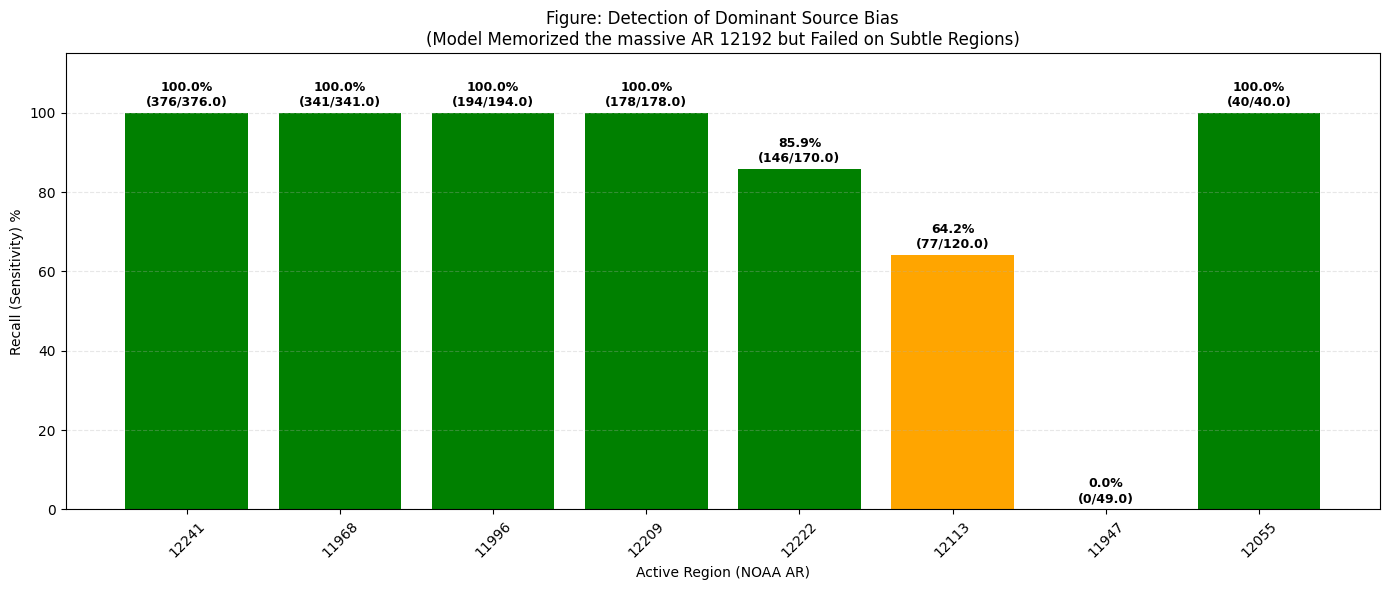

   AR  total  correct   recall
12241    376      376 1.000000
11968    341      341 1.000000
11996    194      194 1.000000
12209    178      178 1.000000
12222    170      146 0.858824
12113    120       77 0.641667
11947     49        0 0.000000
12055     40       40 1.000000


In [5]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit

# ==========================
# CONFIGURATION
# ==========================
MODEL_FILE = "best_xgb_params.joblib"
DATA_FILE = "final_arsenal_300_features_OPTIMIZED.parquet"
GROUP_COL = "HARPNUM"
LABEL_COL = "flare"
AR_COL = "NOAA_AR"
RANDOM_STATE = 35

# ==========================
# 1. LOAD MODEL AND DATA
# ==========================
bundle = joblib.load(MODEL_FILE)
model = bundle['model']
scaler = bundle['scaler']
features = bundle['features']

df = pd.read_parquet(DATA_FILE)
if LABEL_COL not in df.columns:
    mapping = {'Non-flare': 0}
    df[LABEL_COL] = df['classification'].map(mapping).fillna(1).astype(int)

# ==========================
# 2. RECREATE EXACT SAME SPLIT
# ==========================
gss = GroupShuffleSplit(n_splits=1, test_size=0.10, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(df, y=df[LABEL_COL], groups=df[GROUP_COL]))
test_df = df.iloc[test_idx].copy()

X_test = scaler.transform(test_df[features].values)
y_test = test_df[LABEL_COL].values
y_probs = model.predict_proba(X_test)[:, 1]

THRESHOLD = bundle['threshold']
y_pred = (y_probs >= THRESHOLD).astype(int)

# ==========================
# 3. PER-AR RECALL ANALYSIS
# ==========================
test_df['predicted'] = y_pred
test_df['true_label'] = y_test

flare_test = test_df[test_df[LABEL_COL] == 1]
ar_groups = flare_test.groupby(AR_COL)

results = []
for ar, group in ar_groups:
    total = len(group)
    correct = group['predicted'].sum()
    recall = correct / total
    results.append({
        'AR': ar,
        'total': total,
        'correct': correct,
        'recall': recall
    })

results_df = pd.DataFrame(results).sort_values('total', ascending=False)

# ==========================
# 4. PLOT
# ==========================
colors = ['green' if r >= 0.7 else 'orange' if r >= 0.3 else 'red' 
          for r in results_df['recall']]

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(results_df['AR'].astype(str), 
              results_df['recall'] * 100, 
              color=colors)

for bar, (_, row) in zip(bars, results_df.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
            f"{row['recall']*100:.1f}%\n({int(row['correct'])}/{row['total']})",
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Active Region (NOAA AR)')
ax.set_ylabel('Recall (Sensitivity) %')
ax.set_title('Figure: Detection of Dominant Source Bias\n(Model Memorized the massive AR 12192 but Failed on Subtle Regions)')
ax.set_ylim(0, 115)
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('dominant_source_bias_updated.png', dpi=300)
plt.show()

print(results_df.to_string(index=False))

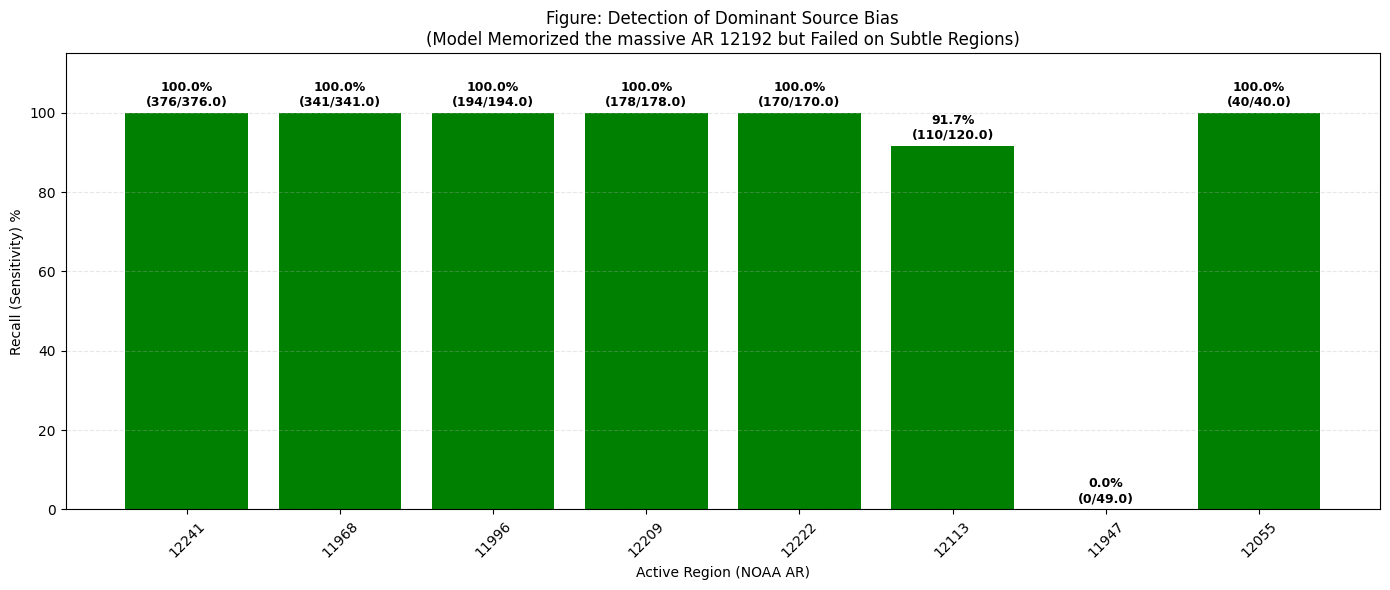

   AR  total  correct   recall
12241    376      376 1.000000
11968    341      341 1.000000
11996    194      194 1.000000
12209    178      178 1.000000
12222    170      170 1.000000
12113    120      110 0.916667
11947     49        0 0.000000
12055     40       40 1.000000


In [1]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit

# ==========================
# CONFIGURATION
# ==========================
MODEL_FILE = "brf_tuned_full_bundle.joblib"
DATA_FILE = "final_arsenal_300_features_OPTIMIZED.parquet"
GROUP_COL = "HARPNUM"
LABEL_COL = "flare"
AR_COL = "NOAA_AR"
RANDOM_STATE = 35

# ==========================
# 1. LOAD MODEL AND DATA
# ==========================
bundle = joblib.load(MODEL_FILE)
model = bundle['model']
scaler = bundle['scaler']
features = bundle['features']

df = pd.read_parquet(DATA_FILE)
if LABEL_COL not in df.columns:
    mapping = {'Non-flare': 0}
    df[LABEL_COL] = df['classification'].map(mapping).fillna(1).astype(int)

# ==========================
# 2. RECREATE EXACT SAME SPLIT
# ==========================
gss = GroupShuffleSplit(n_splits=1, test_size=0.10, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(df, y=df[LABEL_COL], groups=df[GROUP_COL]))
test_df = df.iloc[test_idx].copy()

X_test = scaler.transform(test_df[features].values)
y_test = test_df[LABEL_COL].values
y_probs = model.predict_proba(X_test)[:, 1]

THRESHOLD = bundle['threshold']
y_pred = (y_probs >= THRESHOLD).astype(int)

# ==========================
# 3. PER-AR RECALL ANALYSIS
# ==========================
test_df['predicted'] = y_pred
test_df['true_label'] = y_test

flare_test = test_df[test_df[LABEL_COL] == 1]
ar_groups = flare_test.groupby(AR_COL)

results = []
for ar, group in ar_groups:
    total = len(group)
    correct = group['predicted'].sum()
    recall = correct / total
    results.append({
        'AR': ar,
        'total': total,
        'correct': correct,
        'recall': recall
    })

results_df = pd.DataFrame(results).sort_values('total', ascending=False)

# ==========================
# 4. PLOT
# ==========================
colors = ['green' if r >= 0.7 else 'orange' if r >= 0.3 else 'red' 
          for r in results_df['recall']]

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(results_df['AR'].astype(str), 
              results_df['recall'] * 100, 
              color=colors)

for bar, (_, row) in zip(bars, results_df.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
            f"{row['recall']*100:.1f}%\n({int(row['correct'])}/{row['total']})",
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Active Region (NOAA AR)')
ax.set_ylabel('Recall (Sensitivity) %')
ax.set_title('Figure: Detection of Dominant Source Bias\n(Model Memorized the massive AR 12192 but Failed on Subtle Regions)')
ax.set_ylim(0, 115)
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('dominant_source_bias_updated.png', dpi=300)
plt.show()

print(results_df.to_string(index=False))

In [1]:
import numpy as np
import pandas as pd
import joblib
from xgboost import XGBClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings("ignore")

# ==========================
# CONFIGURATION
# Must match your ablation BRF exactly
# ==========================
DATA_FILE = "final_arsenal_300_features_OPTIMIZED.parquet"
OUTPUT_FILE = "xgboost_ablation_baseline.joblib"

GROUP_COL = "HARPNUM"
LABEL_COL = "flare"
RANDOM_STATE = 35       # Same golden seed as ablation BRF
TEST_GROUP_FRAC = 0.10  # Same split

# ==========================
# 1. LOAD DATA
# ==========================
print("\n--- 1. Loading Dataset ---")
df = pd.read_parquet(DATA_FILE)

if LABEL_COL not in df.columns and 'classification' in df.columns:
    mapping = {'Non-flare': 0}
    df[LABEL_COL] = df['classification'].map(mapping).fillna(1).astype(int)

# ==========================
# 2. DEFINE SAME 55-FEATURE ABLATION SET
# Identical to your BRF ablation — no rolling stats
# ==========================
explicit_drops = [LABEL_COL, GROUP_COL, 'classification', 'NOAA_AR']
rolling_suffixes = ('_mean3', '_std3', '_min3', '_max3', '_slope3')

numeric_df = df.select_dtypes(include=['number'])
feature_names = [
    c for c in numeric_df.columns
    if c not in explicit_drops
    and not c.endswith(rolling_suffixes)
]

print(f"✅ Feature Set: {len(feature_names)} features (should be 55)")
print(f"   Sample: {feature_names[:5]}")

# ==========================
# 3. SAME SPLIT AS BRF ABLATION
# ==========================
print(f"\n--- 2. Creating Split (Seed {RANDOM_STATE}) ---")
gss = GroupShuffleSplit(n_splits=1, test_size=TEST_GROUP_FRAC, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(df, y=df[LABEL_COL], groups=df[GROUP_COL]))

train_df = df.iloc[train_idx].copy()
test_df  = df.iloc[test_idx].copy()

X_train = train_df[feature_names].values
y_train = train_df[LABEL_COL].values
X_test  = test_df[feature_names].values
y_test  = test_df[LABEL_COL].values

print(f"✅ Train: {len(y_train):,} samples, {sum(y_train):,} flares")
print(f"✅ Test:  {len(y_test):,} samples,  {sum(y_test):,} flares")

# Sanity check — should match BRF ablation exactly
assert len(y_train) == 517418, f"Train size mismatch: {len(y_train)}"
assert sum(y_test) == 1468,    f"Test positive count mismatch: {sum(y_test)}"
print("✅ Split matches BRF ablation exactly.")

# ==========================
# 4. SCALE
# ==========================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ==========================
# 5. TRAIN XGBOOST
# Same class imbalance handling strategy as your existing XGBoost runs
# ==========================
neg = np.sum(y_train == 0)
pos = np.sum(y_train == 1)
scale_pos_weight = neg / pos
print(f"\n--- 3. Training XGBoost ---")
print(f"   scale_pos_weight: {scale_pos_weight:.2f}")

model_xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    tree_method='hist',
    n_jobs=-1,
    random_state=42
)
model_xgb.fit(X_train_scaled, y_train)
print("✅ Training complete.")

# ==========================
# 6. THRESHOLD SCAN
# This is the critical step the paper was missing
# ==========================
print("\n--- 4. Threshold Scan (0.01 to 0.99) ---")
y_probs = model_xgb.predict_proba(X_test_scaled)[:, 1]

best_tss       = -1
best_threshold = 0.5
best_recall    = 0
best_fp        = 0
results        = []

for thresh in np.linspace(0.01, 0.99, 200):
    y_pred = (y_probs >= thresh).astype(int)
    
    # Handle edge case where model predicts all one class
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr    = fp / (fp + tn) if (fp + tn) > 0 else 0
    tss    = recall - fpr

    results.append({
        'threshold': round(thresh, 4),
        'tss':       round(tss, 4),
        'recall':    round(recall, 4),
        'fp':        fp,
        'fn':        fn,
        'tp':        tp,
        'tn':        tn
    })

    if tss > best_tss:
        best_tss       = tss
        best_threshold = thresh
        best_recall    = recall
        best_fp        = fp

print(f"\n🏆 XGBoost Best TSS: {best_tss:.4f} at threshold {best_threshold:.4f}")
print(f"   Recall at best TSS: {best_recall:.4f}")
print(f"   False positives:    {best_fp}")

# ==========================
# 7. PRINT TOP 10 THRESHOLDS
# ==========================
results_df = pd.DataFrame(results).sort_values('tss', ascending=False)
print("\nTop 10 Thresholds by TSS:")
print(f"{'Threshold':<12} | {'TSS':<8} | {'Recall':<8} | {'FP':<10} | {'FN':<6}")
print("-" * 52)
for _, row in results_df.head(10).iterrows():
    print(f"{row['threshold']:<12.4f} | {row['tss']:<8.4f} | {row['recall']:<8.4f} | {int(row['fp']):<10} | {int(row['fn']):<6}")

# ==========================
# 8. FINAL EVALUATION AT BEST THRESHOLD
# ==========================
print(f"\n--- 5. Final Evaluation at Threshold {best_threshold:.4f} ---")
y_pred_final = (y_probs >= best_threshold).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_final, labels=[0, 1]).ravel()

recall    = tp / (tp + fn)
fpr       = fp / (fp + tn)
tss       = recall - fpr
precision = tp / (tp + fp) if (tp + fp) > 0 else 0

print("\n" + "="*50)
print("XGBOOST ABLATION BASELINE RESULTS")
print("(Fair comparison: threshold-optimized, same split as BRF)")
print("="*50)
print(f"Confusion Matrix:\n[[{tn}  {fp}]\n [{fn}    {tp}]]")
print("-"*50)
print(f"TSS SCORE:   {tss:.4f}  ← USE THIS IN TABLE 2")
print(f"RECALL:      {recall:.4f}")
print(f"PRECISION:   {precision:.4f}")
print(f"FALSE POS:   {fp}")
print(f"FALSE NEG:   {fn}")
print("="*50)

# ==========================
# 9. OVERFITTING CHECK
# ==========================
print("\n--- 6. Overfitting Check ---")
y_probs_train = model_xgb.predict_proba(X_train_scaled)[:, 1]
y_pred_train  = (y_probs_train >= best_threshold).astype(int)
tn_tr, fp_tr, fn_tr, tp_tr = confusion_matrix(y_train, y_pred_train, labels=[0, 1]).ravel()
recall_tr = tp_tr / (tp_tr + fn_tr)
fpr_tr    = fp_tr / (fp_tr + tn_tr)
tss_train = recall_tr - fpr_tr

print(f"Train TSS: {tss_train:.4f}")
print(f"Test TSS:  {tss:.4f}")
print(f"Gap:       {tss_train - tss:.4f}")

# ==========================
# 10. SAVE
# ==========================
bundle = {
    'model':          model_xgb,
    'scaler':         scaler,
    'features':       feature_names,
    'best_threshold': best_threshold,
    'best_tss':       best_tss
}
joblib.dump(bundle, OUTPUT_FILE)
print(f"\n✅ Saved to {OUTPUT_FILE}")

# ==========================
# 11. PAPER-READY COMPARISON SUMMARY
# ==========================
print("\n" + "="*60)
print("PAPER TABLE 2 UPDATE")
print("="*60)
print(f"BRF (55 features, no rolling):  TSS = 0.6870, Recall = 93.6%")
print(f"XGBoost (55 features, tuned):   TSS = {best_tss:.4f}, Recall = {best_recall*100:.1f}%")
print(f"BRF advantage:                  {0.6870 - best_tss:.4f} TSS points")
print("="*60)


--- 1. Loading Dataset ---
✅ Feature Set: 55 features (should be 55)
   Sample: ['USFLUX', 'MEANGAM', 'MEANGBT', 'MEANGBZ', 'MEANGBH']

--- 2. Creating Split (Seed 35) ---
✅ Train: 517,418 samples, 5,913 flares
✅ Test:  61,575 samples,  1,468 flares
✅ Split matches BRF ablation exactly.

--- 3. Training XGBoost ---
   scale_pos_weight: 86.51
✅ Training complete.

--- 4. Threshold Scan (0.01 to 0.99) ---

🏆 XGBoost Best TSS: 0.3292 at threshold 0.0100
   Recall at best TSS: 0.4441
   False positives:    6907

Top 10 Thresholds by TSS:
Threshold    | TSS      | Recall   | FP         | FN    
----------------------------------------------------
0.0100       | 0.3292   | 0.4441   | 6907       | 816   
0.0149       | 0.2842   | 0.3822   | 5888       | 907   
0.0198       | 0.2609   | 0.3460   | 5118       | 960   
0.0248       | 0.2283   | 0.3052   | 4619       | 1020  
0.0297       | 0.2104   | 0.2813   | 4264       | 1055  
0.0346       | 0.1871   | 0.2534   | 3985       | 1096  
0.0395 

In [1]:
import numpy as np
import pandas as pd
import joblib
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

# ==========================
# CONFIGURATION
# ==========================
DATA_FILE = "final_arsenal_300_features_OPTIMIZED.parquet"
BEST_PARAMS_FILE = "best_brf_params.joblib"
OUTPUT_FILE = "ablation_no_rolling_model.joblib"

GROUP_COL = "HARPNUM"
LABEL_COL = "flare"
RANDOM_STATE = 35
TEST_GROUP_FRAC = 0.10

# ==========================
# 1. LOAD DATA
# ==========================
print("\n--- 1. Loading Dataset ---")
df = pd.read_parquet(DATA_FILE)

if LABEL_COL not in df.columns and 'classification' in df.columns:
    mapping = {'Non-flare': 0}
    df[LABEL_COL] = df['classification'].map(mapping).fillna(1).astype(int)

# ==========================
# 2. DEFINE ABLATION FEATURE SET
# -- Remove ALL rolling stats, keep only base SHARP + deltas
# ==========================
explicit_drops = [LABEL_COL, GROUP_COL, 'classification', 'NOAA_AR']

# Rolling stat suffixes to exclude
rolling_suffixes = ('_mean3', '_std3', '_min3', '_max3', '_slope3')

numeric_df = df.select_dtypes(include=['number'])
feature_names = [
    c for c in numeric_df.columns
    if c not in explicit_drops
    and not c.endswith(rolling_suffixes)
]

print(f"✅ Ablation Feature Set: {len(feature_names)} features (rolling stats removed)")
print(f"   Sample features: {feature_names[:5]}")

# ==========================
# 3. SPLIT
# ==========================
from sklearn.model_selection import train_test_split

print(f"\n--- 2. Creating Split (Random train_test_split, seed {RANDOM_STATE}) ---")

train_df, test_df = train_test_split(df, test_size=TEST_GROUP_FRAC, random_state=RANDOM_STATE)

X_train = train_df[feature_names].values
y_train = train_df[LABEL_COL].values

X_test = test_df[feature_names].values
y_test = test_df[LABEL_COL].values

print(f"✅ Train: {len(y_train)} samples, {sum(y_train)} flares")
print(f"✅ Test:  {len(y_test)} samples, {sum(y_test)} flares")

# ==========================
# 4. SCALE
# ==========================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================
# 5. TRAIN
# ==========================
print("\n--- 3. Training Ablation Model ---")
best_params = joblib.load(BEST_PARAMS_FILE)
best_params['random_state'] = RANDOM_STATE
best_params['n_jobs'] = -1

model = BalancedRandomForestClassifier(**best_params)
model.fit(X_train_scaled, y_train)
print("✅ Training Complete.")

# ==========================
# 6. THRESHOLD SCAN
# ==========================
print("\n--- 4. Threshold Scan (0.30 to 0.95) ---")
y_probs = model.predict_proba(X_test_scaled)[:, 1]

best_tss = 0
best_threshold = 0.5
results = []

for thresh in np.linspace(0.30, 0.95, 66):
    y_pred = (y_probs >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    tss = recall - fpr
    results.append((round(thresh, 3), tss, recall, fp))
    if tss > best_tss:
        best_tss = tss
        best_threshold = thresh

print(f"\n✅ Best Threshold: {best_threshold:.2f} → TSS: {best_tss:.4f}")
print("\nTop 10 Thresholds by TSS:")
results_sorted = sorted(results, key=lambda x: x[1], reverse=True)[:10]
for thresh, tss, recall, fp in results_sorted:
    print(f"   Threshold: {thresh:.2f} | TSS: {tss:.4f} | Recall: {recall:.4f} | FP: {fp}")

# ==========================
# 7. FINAL EVALUATION
# ==========================
print(f"\n--- 5. Final Evaluation at Threshold {best_threshold:.2f} ---")
y_pred_final = (y_probs >= best_threshold).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_final).ravel()

recall = tp / (tp + fn) if (tp + fn) > 0 else 0
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
tss = recall - (fp / (fp + tn))

# Train TSS for overfitting check
y_probs_train = model.predict_proba(X_train_scaled)[:, 1]
y_pred_train = (y_probs_train >= best_threshold).astype(int)
tn_tr, fp_tr, fn_tr, tp_tr = confusion_matrix(y_train, y_pred_train).ravel()
recall_tr = tp_tr / (tp_tr + fn_tr) if (tp_tr + fn_tr) > 0 else 0
fpr_tr = fp_tr / (fp_tr + tn_tr) if (fp_tr + tn_tr) > 0 else 0
tss_train = recall_tr - fpr_tr

print("\n" + "="*40)
print("ABLATION RESULTS (No Rolling Stats)")
print("="*40)
print(f"Features Used: {len(feature_names)}")
print(f"Confusion Matrix:\n[[{tn}  {fp}]\n [{fn}    {tp}]]")
print("-"*25)
print(f"TSS SCORE:    {tss:.4f}")
print(f"RECALL:       {recall:.4f}")
print(f"PRECISION:    {precision:.4f}")
print(f"FALSE POS:    {fp}")
print("-"*25)
print(f"OVERFITTING CHECK:")
print(f"   Train TSS: {tss_train:.4f}")
print(f"   Test TSS:  {tss:.4f}")
gap = tss_train - tss
if gap > 0.15:
    print(f"WARNING: Overfitting gap still present (Gap: {gap:.4f})")
    print("   Rolling stats are NOT the sole cause -- investigate further.")
else:
    print(f"OK: Gap reduced significantly (Gap: {gap:.4f})")
    print("   Rolling stats were causing overfitting -- confirmed.")
print("="*40)

# ==========================
# 8. COMPARISON SUMMARY
# ==========================
print("\n" + "="*40)
print("COMPARISON SUMMARY")
print("="*40)
print(f"Full Model (with rolling):  TSS=0.6583, Gap=0.1810")
print(f"Ablation (no rolling):      TSS={tss:.4f}, Gap={gap:.4f}")
print("="*40)

# ==========================
# 9. SAVE
# ==========================
final_bundle = {
    "model": model,
    "scaler": scaler,
    "features": feature_names,
    "threshold": best_threshold,
    "metrics": {
        "tss": tss,
        "tss_train": tss_train,
        "recall": recall,
        "precision": precision,
        "fp": fp
    },
    "note": "Ablation model -- rolling stats removed"
}
joblib.dump(final_bundle, OUTPUT_FILE)
print(f"\n✅ SAVED: {OUTPUT_FILE}")


--- 1. Loading Dataset ---
✅ Ablation Feature Set: 55 features (rolling stats removed)
   Sample features: ['USFLUX', 'MEANGAM', 'MEANGBT', 'MEANGBZ', 'MEANGBH']

--- 2. Creating Split (Random train_test_split, seed 35) ---
✅ Train: 521093 samples, 6666 flares
✅ Test:  57900 samples, 715 flares

--- 3. Training Ablation Model ---
✅ Training Complete.

--- 4. Threshold Scan (0.30 to 0.95) ---

✅ Best Threshold: 0.95 → TSS: 0.9175

Top 10 Thresholds by TSS:
   Threshold: 0.95 | TSS: 0.9175 | Recall: 0.9790 | FP: 3519
   Threshold: 0.94 | TSS: 0.9159 | Recall: 0.9860 | FP: 4011
   Threshold: 0.93 | TSS: 0.9102 | Recall: 0.9874 | FP: 4417
   Threshold: 0.92 | TSS: 0.9064 | Recall: 0.9902 | FP: 4792
   Threshold: 0.91 | TSS: 0.9039 | Recall: 0.9930 | FP: 5097
   Threshold: 0.90 | TSS: 0.8990 | Recall: 0.9930 | FP: 5375
   Threshold: 0.89 | TSS: 0.8976 | Recall: 0.9958 | FP: 5618
   Threshold: 0.88 | TSS: 0.8944 | Recall: 0.9972 | FP: 5877
   Threshold: 0.87 | TSS: 0.8915 | Recall: 0.9972 |

In [3]:
"""
XGBoost Optuna Hyperparameter Tuning
Matches BRF evaluation setup: GroupShuffleSplit seed 35, HARPNUM grouping,
GroupKFold CV, TSS objective.

Optimized for: AMD Ryzen 7 5700HS (Zen 3, 8 physical cores / 16 threads)

Parallelism strategy:
  - 4 parallel Optuna workers (n_jobs=4 in study.optimize)
  - XGBoost nthread=4 per trial (4 physical cores each)
  - Total: 4 × 4 = 16 logical threads -- fully saturates the 5700HS
  - Zen 3 SMT handles mixed compute well; 4×4 beats 8×2 for XGBoost trees
  - Each worker copies ~290MB of data -- fine on 16GB RAM (4 × 290MB = ~1.2GB)

  If thermal throttling kicks in (laptop gets very hot):
    Drop to OPTUNA_WORKERS=2, XGB_THREADS=4 (8 threads, cooler run)
  If MemoryError:
    Drop to OPTUNA_WORKERS=1, XGB_THREADS=8 (sequential, no duplication)

  Plug in the charger before running -- this will peg all cores.
"""

import numpy as np
import pandas as pd
import optuna
import joblib
from xgboost import XGBClassifier
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings("ignore")

optuna.logging.set_verbosity(optuna.logging.WARNING)

# ==========================
# CONFIGURATION
# ==========================
DATA_FILE          = "final_arsenal_300_features_OPTIMIZED.parquet"
OUTPUT_FILE        = "best_xgb_params.joblib"
GROUP_COL          = "HARPNUM"
LABEL_COL          = "flare"
RANDOM_STATE       = 35          # same seed as BRF evaluation
TEST_GROUP_FRAC    = 0.10        # same 90/10 split as BRF
N_TRIALS           = 50          # same as BRF Optuna run
N_CV_FOLDS         = 5           # GroupKFold folds for CV

# Ryzen 7 5700HS: 8 physical cores / 16 threads (Zen 3 SMT)
# 4 workers x 4 threads = 16 logical threads -- full saturation
# Fallback if hot: OPTUNA_WORKERS=2, XGB_THREADS=4
# Fallback if MemoryError: OPTUNA_WORKERS=1, XGB_THREADS=8
OPTUNA_WORKERS     = 4
XGB_THREADS        = 4

# Rolling stat suffixes to drop (match BRF ablation feature set)
ROLLING_SUFFIXES   = ('_mean3', '_std3', '_min3', '_max3', '_slope3')

# ==========================
# 1. LOAD DATA
# ==========================
print("\n--- 1. Loading Dataset ---")
df = pd.read_parquet(DATA_FILE)

if LABEL_COL not in df.columns and 'classification' in df.columns:
    mapping = {'Non-flare': 0}
    df[LABEL_COL] = df['classification'].map(mapping).fillna(1).astype(int)

# ==========================
# 2. BUILD 55-FEATURE SET
# (identical to BRF ablation)
# ==========================
explicit_drops = [LABEL_COL, GROUP_COL, 'classification', 'NOAA_AR']
numeric_df     = df.select_dtypes(include=['number'])
feature_names  = [
    c for c in numeric_df.columns
    if c not in explicit_drops
    and not c.endswith(ROLLING_SUFFIXES)
]
print(f"Feature set: {len(feature_names)} features (rolling stats removed)")

# ==========================
# 3. TRAIN/TEST SPLIT
# (identical seed 35 GroupShuffleSplit as BRF)
# ==========================
print(f"\n--- 2. Creating Split (Seed {RANDOM_STATE}) ---")
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=TEST_GROUP_FRAC,
    random_state=RANDOM_STATE
)
train_idx, test_idx = next(
    gss.split(df, y=df[LABEL_COL], groups=df[GROUP_COL])
)

train_df = df.iloc[train_idx].copy()
test_df  = df.iloc[test_idx].copy()

X_train = train_df[feature_names].values
y_train = train_df[LABEL_COL].values
X_test  = test_df[feature_names].values
y_test  = test_df[LABEL_COL].values
groups_train = train_df[GROUP_COL].values

print(f"Train: {len(y_train)} samples, {sum(y_train)} flares")
print(f"Test:  {len(y_test)} samples, {sum(y_test)} flares")

# ==========================
# 4. SCALE
# ==========================
scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train)
X_test_sc   = scaler.transform(X_test)

# ==========================
# 5. TSS HELPER
# ==========================
def tss_score(y_true, y_pred):
    try:
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        fpr    = fp / (fp + tn) if (fp + tn) > 0 else 0
        return recall - fpr
    except ValueError:
        return 0.0

# ==========================
# 6. SCALE_POS_WEIGHT
# (fixed, not tuned -- matches imbalance ratio)
# ==========================
neg_count       = np.sum(y_train == 0)
pos_count       = np.sum(y_train == 1)
scale_pos_wt    = neg_count / pos_count
print(f"\nscale_pos_weight (fixed): {scale_pos_wt:.2f}")

# ==========================
# 7. OPTUNA OBJECTIVE
# ==========================
def objective(trial):
    params = {
        "n_estimators":       trial.suggest_int("n_estimators", 100, 800),
        "max_depth":          trial.suggest_int("max_depth", 3, 10),
        "learning_rate":      trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample":          trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":   trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight":   trial.suggest_int("min_child_weight", 1, 20),
        "gamma":              trial.suggest_float("gamma", 0.0, 2.0),
        "reg_alpha":          trial.suggest_float("reg_alpha", 0.0, 2.0),
        "reg_lambda":         trial.suggest_float("reg_lambda", 0.5, 5.0),
        # fixed
        "scale_pos_weight":   scale_pos_wt,
        "objective":          "binary:logistic",
        "eval_metric":        "logloss",
        "use_label_encoder":  False,
        "nthread":            XGB_THREADS,
        "random_state":       RANDOM_STATE,
    }

    gkf    = GroupKFold(n_splits=N_CV_FOLDS)
    scores = []

    for fold_train_idx, fold_val_idx in gkf.split(
        X_train_sc, y_train, groups=groups_train
    ):
        X_fold_train = X_train_sc[fold_train_idx]
        y_fold_train = y_train[fold_train_idx]
        X_fold_val   = X_train_sc[fold_val_idx]
        y_fold_val   = y_train[fold_val_idx]

        model = XGBClassifier(**params)
        model.fit(
            X_fold_train, y_fold_train,
            eval_set=[(X_fold_val, y_fold_val)],
            verbose=False
        )

        # threshold scan on validation fold
        probs     = model.predict_proba(X_fold_val)[:, 1]
        best_tss  = 0.0
        for thresh in np.linspace(0.30, 0.95, 66):
            preds    = (probs >= thresh).astype(int)
            fold_tss = tss_score(y_fold_val, preds)
            if fold_tss > best_tss:
                best_tss = fold_tss
        scores.append(best_tss)

    return np.mean(scores)

# ==========================
# 8. RUN OPTUNA
# ==========================
print(f"\n--- 3. Running Optuna ({N_TRIALS} trials, {OPTUNA_WORKERS} parallel workers) ---")
print(f"   XGBoost threads per trial: {XGB_THREADS}")
print(f"   Total cores in use: {OPTUNA_WORKERS * XGB_THREADS}")
print("   This will take a while. Progress prints every 10 trials.\n")

study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)

completed = [0]

def progress_callback(study, trial):
    completed[0] += 1
    if completed[0] % 10 == 0:
        print(f"   [{completed[0]}/{N_TRIALS}] Best TSS so far: {study.best_value:.4f}")

study.optimize(
    objective,
    n_trials=N_TRIALS,
    n_jobs=OPTUNA_WORKERS,
    callbacks=[progress_callback],
    show_progress_bar=False
)

print(f"\n✅ Best CV TSS:  {study.best_value:.4f}")
print(f"   Best params: {study.best_params}")

# ==========================
# 9. FINAL EVALUATION ON TEST SET
# ==========================
print("\n--- 4. Final Evaluation on Held-Out Test Set ---")

best_params = study.best_params.copy()
best_params.update({
    "scale_pos_weight":  scale_pos_wt,
    "objective":         "binary:logistic",
    "eval_metric":       "logloss",
    "use_label_encoder": False,
    "nthread":           -1,       # use all cores for final training
    "random_state":      RANDOM_STATE,
})

final_model = XGBClassifier(**best_params)
final_model.fit(X_train_sc, y_train)

probs        = final_model.predict_proba(X_test_sc)[:, 1]
best_tss     = 0.0
best_thresh  = 0.5
results      = []

for thresh in np.linspace(0.30, 0.95, 66):
    preds    = (probs >= thresh).astype(int)
    t        = tss_score(y_test, preds)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    recall   = tp / (tp + fn) if (tp + fn) > 0 else 0
    results.append((round(thresh, 3), t, recall, fp))
    if t > best_tss:
        best_tss    = t
        best_thresh = thresh

results_sorted = sorted(results, key=lambda x: x[1], reverse=True)

print(f"\n✅ Best Threshold: {best_thresh:.2f} → TSS: {best_tss:.4f}")
print("\nTop 5 Thresholds:")
for thresh, tss, recall, fp in results_sorted[:5]:
    print(f"   Threshold: {thresh:.2f} | TSS: {tss:.4f} | Recall: {recall:.4f} | FP: {fp}")

# Final metrics at best threshold
y_pred_final             = (probs >= best_thresh).astype(int)
tn, fp, fn, tp           = confusion_matrix(y_test, y_pred_final).ravel()
recall                   = tp / (tp + fn)
precision                = tp / (tp + fp) if (tp + fp) > 0 else 0

# Train TSS for overfitting check
train_probs              = final_model.predict_proba(X_train_sc)[:, 1]
train_preds              = (train_probs >= best_thresh).astype(int)
tss_train                = tss_score(y_train, train_preds)

print("\n" + "="*45)
print("XGBoost TUNED RESULTS (Optuna, 50 trials)")
print("="*45)
print(f"Features:      {len(feature_names)} (same as BRF ablation)")
print(f"Split:         GroupShuffleSplit seed 35 (same as BRF)")
print(f"Imbalance:     scale_pos_weight = {scale_pos_wt:.1f}")
print(f"\nConfusion Matrix:")
print(f"  [[{tn}  {fp}]")
print(f"   [{fn}    {tp}]]")
print(f"\nTSS:       {best_tss:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"Precision: {precision:.4f}")
print(f"FP:        {fp}")
print(f"\nOverfitting check:")
print(f"  Train TSS: {tss_train:.4f}")
print(f"  Test TSS:  {best_tss:.4f}")
print(f"  Gap:       {tss_train - best_tss:.4f}")
print("="*45)

print("\n" + "="*45)
print("COMPARISON SUMMARY")
print("="*45)
print(f"BRF (Optuna tuned, 50 trials):  TSS = 0.6870")
print(f"XGB (Optuna tuned, 50 trials):  TSS = {best_tss:.4f}")
print(f"Advantage (BRF - XGB):          {0.6870 - best_tss:+.4f}")
print("="*45)

# ==========================
# 10. SAVE
# ==========================
bundle = {
    "model":          final_model,
    "scaler":         scaler,
    "features":       feature_names,
    "threshold":      best_thresh,
    "best_params":    best_params,
    "study":          study,
    "metrics": {
        "tss":        best_tss,
        "tss_train":  tss_train,
        "recall":     recall,
        "precision":  precision,
        "fp":         fp,
    }
}
joblib.dump(bundle, OUTPUT_FILE)
print(f"\n✅ Saved: {OUTPUT_FILE}")


--- 1. Loading Dataset ---
Feature set: 55 features (rolling stats removed)

--- 2. Creating Split (Seed 35) ---
Train: 517418 samples, 5913 flares
Test:  61575 samples, 1468 flares

scale_pos_weight (fixed): 86.51

--- 3. Running Optuna (50 trials, 4 parallel workers) ---
   XGBoost threads per trial: 4
   Total cores in use: 16
   This will take a while. Progress prints every 10 trials.

   [10/50] Best TSS so far: 0.6544
   [20/50] Best TSS so far: 0.7776
   [30/50] Best TSS so far: 0.7776
   [40/50] Best TSS so far: 0.7805
   [50/50] Best TSS so far: 0.7805

✅ Best CV TSS:  0.7805
   Best params: {'n_estimators': 231, 'max_depth': 3, 'learning_rate': 0.010868971025414734, 'subsample': 0.7519826780558342, 'colsample_bytree': 0.5278525464056406, 'min_child_weight': 17, 'gamma': 0.9404034333141229, 'reg_alpha': 1.5759555220682275, 'reg_lambda': 1.7513932764322577}

--- 4. Final Evaluation on Held-Out Test Set ---

✅ Best Threshold: 0.55 → TSS: 0.7173

Top 5 Thresholds:
   Threshold: 

In [1]:
"""
Balanced Random Forest Optuna Hyperparameter Tuning
Matches XGBoost evaluation setup: GroupShuffleSplit seed 35 (90/10),
HARPNUM grouping, GroupKFold CV within training set, TSS objective.

Optimized for: AMD Ryzen 7 5700HS (Zen 3, 8 physical cores / 16 threads)

Parallelism strategy:
  - 4 parallel Optuna workers (n_jobs=4 in study.optimize)
  - BRF n_jobs=4 per trial (4 physical cores each)
  - Total: 4 × 4 = 16 logical threads -- fully saturates the 5700HS

  If thermal throttling kicks in (laptop gets very hot):
    Drop to OPTUNA_WORKERS=2, BRF_JOBS=4 (8 threads, cooler run)
  If MemoryError:
    Drop to OPTUNA_WORKERS=1, BRF_JOBS=8 (sequential, no duplication)

  Plug in the charger before running -- this will peg all cores.
  NOTE: BRF trees are heavier than XGBoost trees (bootstrap resampling
  per tree), so expect this to run longer than the XGBoost tuning script
  even at the same thread count.
"""

import numpy as np
import pandas as pd
import optuna
import joblib
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings("ignore")

optuna.logging.set_verbosity(optuna.logging.WARNING)

# ==========================
# CONFIGURATION
# ==========================
DATA_FILE          = "final_arsenal_300_features_OPTIMIZED.parquet"
OUTPUT_STUDY_FILE  = "optuna_brf_study.pkl"
BEST_PARAMS_FILE   = "best_brf_params.joblib"
GROUP_COL          = "HARPNUM"
LABEL_COL          = "flare"
RANDOM_STATE       = 35          # same seed as XGBoost evaluation
TEST_GROUP_FRAC    = 0.10        # same 90/10 split as XGBoost
N_TRIALS           = 50          # same as XGBoost Optuna run
N_CV_FOLDS         = 5           # GroupKFold folds for CV

# Ryzen 7 5700HS: 8 physical cores / 16 threads (Zen 3 SMT)
# 4 workers x 4 threads = 16 logical threads -- full saturation
# Fallback if hot: OPTUNA_WORKERS=2, BRF_JOBS=4
# Fallback if MemoryError: OPTUNA_WORKERS=1, BRF_JOBS=8
OPTUNA_WORKERS     = 4
BRF_JOBS           = 4

# Rolling stat suffixes to drop (match XGBoost ablation feature set)
ROLLING_SUFFIXES   = ('_mean3', '_std3', '_min3', '_max3', '_slope3')

# ==========================
# 1. LOAD DATA
# ==========================
print("\n--- 1. Loading Dataset ---")
df = pd.read_parquet(DATA_FILE)

if LABEL_COL not in df.columns and 'classification' in df.columns:
    mapping = {'Non-flare': 0}
    df[LABEL_COL] = df['classification'].map(mapping).fillna(1).astype(int)

# ==========================
# 2. BUILD 55-FEATURE SET
# (identical to XGBoost ablation)
# ==========================
explicit_drops = [LABEL_COL, GROUP_COL, 'classification', 'NOAA_AR']
numeric_df     = df.select_dtypes(include=['number'])
feature_names  = [
    c for c in numeric_df.columns
    if c not in explicit_drops
    and not c.endswith(ROLLING_SUFFIXES)
]
print(f"Feature set: {len(feature_names)} features (rolling stats removed)")

# ==========================
# 3. TRAIN/TEST SPLIT
# (identical seed 35 GroupShuffleSplit as XGBoost)
# ==========================
print(f"\n--- 2. Creating Split (Seed {RANDOM_STATE}) ---")
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=TEST_GROUP_FRAC,
    random_state=RANDOM_STATE
)
train_idx, test_idx = next(
    gss.split(df, y=df[LABEL_COL], groups=df[GROUP_COL])
)

train_df = df.iloc[train_idx].copy()
test_df  = df.iloc[test_idx].copy()

X_train = train_df[feature_names].values
y_train = train_df[LABEL_COL].values
X_test  = test_df[feature_names].values
y_test  = test_df[LABEL_COL].values
groups_train = train_df[GROUP_COL].values

print(f"Train: {len(y_train)} samples, {sum(y_train)} flares")
print(f"Test:  {len(y_test)} samples, {sum(y_test)} flares")

# ==========================
# 4. SCALE
# (full-train scaler for final model; per-fold scalers used inside CV)
# ==========================
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ==========================
# 5. TSS HELPER
# ==========================
def tss_score(y_true, y_pred):
    try:
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        fpr    = fp / (fp + tn) if (fp + tn) > 0 else 0
        return recall - fpr
    except ValueError:
        return 0.0

# ==========================
# 6. OPTUNA OBJECTIVE
# ==========================
def objective(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 100, 300, step=50),
        "max_depth":         trial.suggest_int("max_depth", 5, 25),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf":  trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features":      trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        "sampling_strategy": trial.suggest_categorical("sampling_strategy", ["majority", "not minority", "all"]),
        "class_weight":      trial.suggest_categorical("class_weight", ["balanced", "balanced_subsample"]),
        "random_state":      RANDOM_STATE,
        "n_jobs":            BRF_JOBS,
    }

    gkf    = GroupKFold(n_splits=N_CV_FOLDS)
    scores = []

    for fold_train_idx, fold_val_idx in gkf.split(
        X_train, y_train, groups=groups_train
    ):
        X_fold_train_raw = X_train[fold_train_idx]
        y_fold_train     = y_train[fold_train_idx]
        X_fold_val_raw   = X_train[fold_val_idx]
        y_fold_val       = y_train[fold_val_idx]

        # Fit scaler ONLY on fold-train to prevent leakage
        fold_scaler   = StandardScaler()
        X_fold_train  = fold_scaler.fit_transform(X_fold_train_raw)
        X_fold_val    = fold_scaler.transform(X_fold_val_raw)

        model = BalancedRandomForestClassifier(**params)
        model.fit(X_fold_train, y_fold_train)

        probs    = model.predict_proba(X_fold_val)[:, 1]
        best_tss = 0.0
        for thresh in np.linspace(0.30, 0.95, 66):
            preds    = (probs >= thresh).astype(int)
            fold_tss = tss_score(y_fold_val, preds)
            if fold_tss > best_tss:
                best_tss = fold_tss
        scores.append(best_tss)

    return np.mean(scores)

# ==========================
# 7. RUN OPTUNA
# ==========================
print(f"\n--- 3. Running Optuna ({N_TRIALS} trials, {OPTUNA_WORKERS} parallel workers) ---")
print(f"   BRF n_jobs per trial: {BRF_JOBS}")
print(f"   Total cores in use: {OPTUNA_WORKERS * BRF_JOBS}")
print("   BRF trials are heavier than XGBoost (bootstrap per tree) -- expect a longer run.")
print("   Progress prints every 10 trials.\n")

study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    study_name="BRF_TSS_Optimization"
)

completed = [0]

def progress_callback(study, trial):
    completed[0] += 1
    if completed[0] % 10 == 0:
        print(f"   [{completed[0]}/{N_TRIALS}] Best TSS so far: {study.best_value:.4f}")

study.optimize(
    objective,
    n_trials=N_TRIALS,
    n_jobs=OPTUNA_WORKERS,
    callbacks=[progress_callback],
    show_progress_bar=False
)

print(f"\n✅ Best CV TSS:  {study.best_value:.4f}")
print(f"   Best params: {study.best_params}")

joblib.dump(study, OUTPUT_STUDY_FILE)
joblib.dump(study.best_params, BEST_PARAMS_FILE)
print(f"\n✅ Artifacts Saved: {OUTPUT_STUDY_FILE}, {BEST_PARAMS_FILE}")

# ==========================
# 8. FINAL EVALUATION ON TEST SET
# ==========================
print("\n--- 4. Final Evaluation on Held-Out Test Set ---")

best_params = study.best_params.copy()
best_params.update({
    "random_state": RANDOM_STATE,
    "n_jobs":       -1,   # use all cores for final training
})

final_model = BalancedRandomForestClassifier(**best_params)
final_model.fit(X_train_sc, y_train)

probs       = final_model.predict_proba(X_test_sc)[:, 1]
best_tss    = 0.0
best_thresh = 0.5
results     = []

for thresh in np.linspace(0.30, 0.95, 66):
    preds = (probs >= thresh).astype(int)
    t     = tss_score(y_test, preds)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    results.append((round(thresh, 3), t, recall, fp))
    if t > best_tss:
        best_tss    = t
        best_thresh = thresh

results_sorted = sorted(results, key=lambda x: x[1], reverse=True)

print(f"\n✅ Best Threshold: {best_thresh:.2f} → TSS: {best_tss:.4f}")
print("\nTop 5 Thresholds:")
for thresh, tss, recall, fp in results_sorted[:5]:
    print(f"   Threshold: {thresh:.2f} | TSS: {tss:.4f} | Recall: {recall:.4f} | FP: {fp}")

y_pred_final = (probs >= best_thresh).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_final).ravel()
recall    = tp / (tp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0

# Train TSS for overfitting check
train_probs = final_model.predict_proba(X_train_sc)[:, 1]
train_preds = (train_probs >= best_thresh).astype(int)
tss_train   = tss_score(y_train, train_preds)

print("\n" + "="*45)
print("BRF TUNED RESULTS (Optuna, 50 trials)")
print("="*45)
print(f"Features:      {len(feature_names)} (same as XGBoost ablation)")
print(f"Split:         GroupShuffleSplit seed 35 (same as XGBoost)")
print(f"\nConfusion Matrix:")
print(f"  [[{tn}  {fp}]")
print(f"   [{fn}    {tp}]]")
print(f"\nTSS:       {best_tss:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"Precision: {precision:.4f}")
print(f"FP:        {fp}")
print(f"\nOverfitting check:")
print(f"  Train TSS: {tss_train:.4f}")
print(f"  Test TSS:  {best_tss:.4f}")
print(f"  Gap:       {tss_train - best_tss:.4f}")
print("="*45)

print("\n" + "="*45)
print("COMPARISON SUMMARY")
print("="*45)
print(f"BRF (Optuna tuned, 50 trials):  TSS = {best_tss:.4f}")
print(f"XGB (Optuna tuned, 50 trials):  TSS = 0.7173")
print(f"Advantage (BRF - XGB):          {best_tss - 0.7173:+.4f}")
print("="*45)

# ==========================
# 9. SAVE FULL BUNDLE
# ==========================
bundle = {
    "model":       final_model,
    "scaler":      scaler,
    "features":    feature_names,
    "threshold":   best_thresh,
    "best_params": best_params,
    "study":       study,
    "metrics": {
        "tss":       best_tss,
        "tss_train": tss_train,
        "recall":    recall,
        "precision": precision,
        "fp":        fp,
    }
}
joblib.dump(bundle, "brf_tuned_full_bundle.joblib")
print(f"\n✅ Saved: brf_tuned_full_bundle.joblib")


--- 1. Loading Dataset ---
Feature set: 55 features (rolling stats removed)

--- 2. Creating Split (Seed 35) ---
Train: 517418 samples, 5913 flares
Test:  61575 samples, 1468 flares

--- 3. Running Optuna (50 trials, 4 parallel workers) ---
   BRF n_jobs per trial: 4
   Total cores in use: 16
   BRF trials are heavier than XGBoost (bootstrap per tree) -- expect a longer run.
   Progress prints every 10 trials.

   [10/50] Best TSS so far: 0.7652
   [20/50] Best TSS so far: 0.7686
   [30/50] Best TSS so far: 0.7701
   [40/50] Best TSS so far: 0.7701
   [50/50] Best TSS so far: 0.7701

✅ Best CV TSS:  0.7701
   Best params: {'n_estimators': 250, 'max_depth': 8, 'min_samples_split': 18, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'sampling_strategy': 'all', 'class_weight': 'balanced_subsample'}

✅ Artifacts Saved: optuna_brf_study.pkl, best_brf_params.joblib

--- 4. Final Evaluation on Held-Out Test Set ---

✅ Best Threshold: 0.59 → TSS: 0.6768

Top 5 Thresholds:
   Threshold: 0.59 | 

In [11]:
"""
Final Model Training -- BRF and XGBoost
Uses the best hyperparameters found via 50-trial Optuna search (see
brf_optuna_tuning.py and xgboost_optuna_tuning.py for the search itself).

This script trains BOTH final models on the same GroupShuffleSplit seed 35
split, evaluates both on the same held-out test set, and saves everything
needed for the results section of the paper.
"""

import numpy as np
import pandas as pd
import joblib
from imblearn.ensemble import BalancedRandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings("ignore")

# ==========================
# CONFIGURATION
# ==========================
DATA_FILE        = "final_arsenal_300_features_OPTIMIZED.parquet"
GROUP_COL        = "HARPNUM"
LABEL_COL        = "flare"
RANDOM_STATE     = 35
TEST_GROUP_FRAC  = 0.10
ROLLING_SUFFIXES = ('_mean3', '_std3', '_min3', '_max3', '_slope3')

# Best params found via Optuna (50 trials each, GroupKFold CV, identical
# train split and feature set for both models)
BRF_BEST_PARAMS = {
    "n_estimators":      250,
    "max_depth":         8,
    "min_samples_split": 18,
    "min_samples_leaf":  6,
    "max_features":      "sqrt",
    "sampling_strategy":  "all",
    "class_weight":      "balanced_subsample",
    "random_state":      RANDOM_STATE,
    "n_jobs":            -1,
}
BRF_THRESHOLD = 0.59

XGB_BEST_PARAMS = {
    "n_estimators":      231,
    "max_depth":         3,
    "learning_rate":     0.010868971025414734,
    "subsample":         0.7519826780558342,
    "colsample_bytree":  0.5278525464056406,
    "min_child_weight":  17,
    "gamma":             0.9404034333141229,
    "reg_alpha":         1.5759555220682275,
    "reg_lambda":        1.7513932764322577,
    "objective":         "binary:logistic",
    "eval_metric":       "logloss",
    "use_label_encoder": False,
    "random_state":      RANDOM_STATE,
    "nthread":           -1,
    # scale_pos_weight set after train split, computed from actual ratio
}
XGB_THRESHOLD = 0.55

# ==========================
# 1. LOAD DATA
# ==========================
print("\n--- 1. Loading Dataset ---")
df = pd.read_parquet(DATA_FILE)

if LABEL_COL not in df.columns and 'classification' in df.columns:
    mapping = {'Non-flare': 0}
    df[LABEL_COL] = df['classification'].map(mapping).fillna(1).astype(int)

# ==========================
# 2. BUILD 55-FEATURE SET
# ==========================
explicit_drops = [LABEL_COL, GROUP_COL, 'classification', 'NOAA_AR']
numeric_df     = df.select_dtypes(include=['number'])
feature_names  = [
    c for c in numeric_df.columns
    if c not in explicit_drops
    and not c.endswith(ROLLING_SUFFIXES)
]
print(f"Feature set: {len(feature_names)} features")

# ==========================
# 3. TRAIN/TEST SPLIT (seed 35, identical for both models)
# ==========================
print(f"\n--- 2. Creating Split (Seed {RANDOM_STATE}) ---")
gss = GroupShuffleSplit(n_splits=1, test_size=TEST_GROUP_FRAC, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(df, y=df[LABEL_COL], groups=df[GROUP_COL]))

train_df = df.iloc[train_idx].copy()
test_df  = df.iloc[test_idx].copy()

X_train = train_df[feature_names].values
y_train = train_df[LABEL_COL].values
X_test  = test_df[feature_names].values
y_test  = test_df[LABEL_COL].values

print(f"Train: {len(y_train)} samples, {sum(y_train)} flares")
print(f"Test:  {len(y_test)} samples, {sum(y_test)} flares")

# ==========================
# 4. SCALE
# ==========================
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ==========================
# 5. METRIC HELPERS
# ==========================
def evaluate_at_threshold(y_true, probs, threshold):
    preds = (probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr       = fp / (fp + tn) if (fp + tn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    tss       = recall - fpr
    return {
        "tss": tss, "recall": recall, "precision": precision,
        "tn": tn, "fp": fp, "fn": fn, "tp": tp
    }

def print_results(name, metrics, threshold):
    print(f"\n{'='*45}")
    print(f"{name} -- FINAL RESULTS (threshold={threshold})")
    print(f"{'='*45}")
    print(f"Confusion Matrix:")
    print(f"  [[{metrics['tn']}  {metrics['fp']}]")
    print(f"   [{metrics['fn']}    {metrics['tp']}]]")
    print(f"\nTSS:       {metrics['tss']:.4f}")
    print(f"Recall:    {metrics['recall']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"FP:        {metrics['fp']}")
    print(f"{'='*45}")

# ==========================
# 6. TRAIN BRF (FINAL)
# ==========================
print("\n--- 3. Training Final BRF Model ---")
brf_model = BalancedRandomForestClassifier(**BRF_BEST_PARAMS)
brf_model.fit(X_train_sc, y_train)
print("BRF training complete.")

brf_test_probs  = brf_model.predict_proba(X_test_sc)[:, 1]
brf_train_probs = brf_model.predict_proba(X_train_sc)[:, 1]

brf_test_metrics  = evaluate_at_threshold(y_test, brf_test_probs, BRF_THRESHOLD)
brf_train_metrics = evaluate_at_threshold(y_train, brf_train_probs, BRF_THRESHOLD)

print_results("BRF", brf_test_metrics, BRF_THRESHOLD)
print(f"Train TSS: {brf_train_metrics['tss']:.4f}  |  Overfitting Gap: {brf_train_metrics['tss'] - brf_test_metrics['tss']:.4f}")

# ==========================
# 7. TRAIN XGBOOST (FINAL)
# ==========================
print("\n--- 4. Training Final XGBoost Model ---")

neg_count = np.sum(y_train == 0)
pos_count = np.sum(y_train == 1)
scale_pos_wt = neg_count / pos_count
print(f"scale_pos_weight: {scale_pos_wt:.2f}")

xgb_params = XGB_BEST_PARAMS.copy()
xgb_params["scale_pos_weight"] = scale_pos_wt

xgb_model = XGBClassifier(**xgb_params)
xgb_model.fit(X_train_sc, y_train)
print("XGBoost training complete.")

xgb_test_probs  = xgb_model.predict_proba(X_test_sc)[:, 1]
xgb_train_probs = xgb_model.predict_proba(X_train_sc)[:, 1]

xgb_test_metrics  = evaluate_at_threshold(y_test, xgb_test_probs, XGB_THRESHOLD)
xgb_train_metrics = evaluate_at_threshold(y_train, xgb_train_probs, XGB_THRESHOLD)

print_results("XGBoost", xgb_test_metrics, XGB_THRESHOLD)
print(f"Train TSS: {xgb_train_metrics['tss']:.4f}  |  Overfitting Gap: {xgb_train_metrics['tss'] - xgb_test_metrics['tss']:.4f}")

# ==========================
# 8. FINAL COMPARISON (for paper's results table)
# ==========================
print("\n" + "="*50)
print("FINAL MODEL COMPARISON -- FOR RESULTS SECTION")
print("="*50)
print(f"{'Metric':<15}{'BRF':<15}{'XGBoost':<15}")
print(f"{'TSS':<15}{brf_test_metrics['tss']:<15.4f}{xgb_test_metrics['tss']:<15.4f}")
print(f"{'Recall':<15}{brf_test_metrics['recall']:<15.4f}{xgb_test_metrics['recall']:<15.4f}")
print(f"{'Precision':<15}{brf_test_metrics['precision']:<15.4f}{xgb_test_metrics['precision']:<15.4f}")
print(f"{'FP':<15}{brf_test_metrics['fp']:<15}{xgb_test_metrics['fp']:<15}")
print(f"{'Threshold':<15}{BRF_THRESHOLD:<15}{XGB_THRESHOLD:<15}")
print("="*50)
print(f"\nXGBoost advantage: +{xgb_test_metrics['tss'] - brf_test_metrics['tss']:.4f} TSS")

# ==========================
# 9. SAVE EVERYTHING
# ==========================
print("\n--- 5. Saving Models and Results ---")

joblib.dump({
    "model":     brf_model,
    "scaler":    scaler,
    "features":  feature_names,
    "threshold": BRF_THRESHOLD,
    "params":    BRF_BEST_PARAMS,
    "test_metrics":  brf_test_metrics,
    "train_metrics": brf_train_metrics,
}, "final_brf_model.joblib")

joblib.dump({
    "model":     xgb_model,
    "scaler":    scaler,
    "features":  feature_names,
    "threshold": XGB_THRESHOLD,
    "params":    xgb_params,
    "test_metrics":  xgb_test_metrics,
    "train_metrics": xgb_train_metrics,
}, "final_xgboost_model.joblib")

print("Saved: final_brf_model.joblib")
print("Saved: final_xgboost_model.joblib")
print("\nDone. Use the printed comparison table above directly in your results section.")

Good
